# Classical Mechanics — Numerical Simulations

This notebook collects simulations for the main topics of Classical Mechanics.
Each section is self-contained: it imports its own libraries and defines its own
`initialize` / `observe` helpers so that cells can be run independently.

**Numerical methods used:**
- Euler, Euler–Cromer, Euler–Verlet  (simple fixed-step integrators)
- Runge–Kutta 4 (RK4)               (high-accuracy fixed-step integrator)
- `scipy.integrate.odeint`           (adaptive integrator, used for the double pendulum)

---

## 1. Ideal Projectile Motion

A particle launched with speed $v_0$ at angle $\theta$ under constant gravity $g$,
with **no air resistance**.  The equations of motion are:

$$\dot{x} = v_x, \quad \dot{y} = v_y, \quad \dot{v}_x = 0, \quad \dot{v}_y = -g$$

We integrate these with RK4 and compare trajectories for several launch angles.
The energy error $|\Delta E|$ is tracked to verify numerical accuracy.

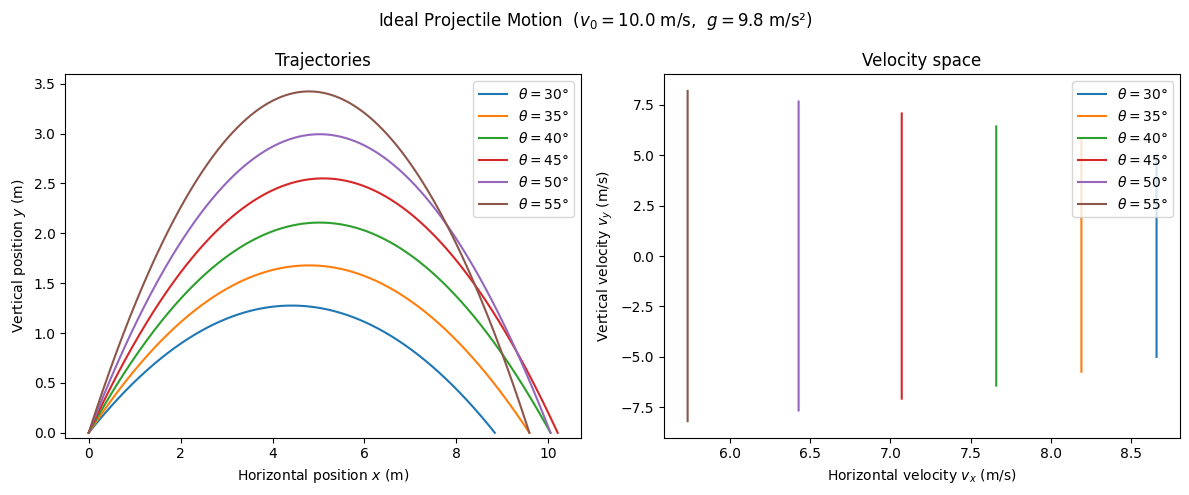

In [18]:
import numpy as np
import matplotlib.pyplot as plt
 
# --- Parameters ---
x0, y0 = 0.0, 0.0   # initial position (m)
v0      = 10.0       # launch speed (m/s)
g       = 9.8        # gravitational acceleration (m/s²)
tf      = 2.0        # total simulation time (s)
Nt      = 20_000     # number of time steps
 
# --- Physics ---
def derivatives_ideal(t, x, y, vx, vy):
    """Time derivatives for ideal (drag-free) projectile: [dx/dt, dy/dt, dvx/dt, dvy/dt]."""
    return [vx, vy, 0.0, -g]
 
def total_energy(vx, vy, y):
    """Specific mechanical energy (per unit mass)."""
    return 0.5 * (vx**2 + vy**2) + g * y
 
# --- State management ---
def initialize(vx_init, vy_init):
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist, time_hist, dE_hist, E0, h
    h  = tf / (Nt - 1)
    t, x, y, vx, vy = 0.0, x0, y0, vx_init, vy_init
    E0 = total_energy(vx, vy, y)
    x_hist, y_hist   = [x],  [y]
    vx_hist, vy_hist = [vx], [vy]
    time_hist        = [t]
    dE_hist          = [0.0]
 
def observe():
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist, time_hist, dE_hist, E0
    time_hist.append(t)
    x_hist.append(x);   y_hist.append(y)
    vx_hist.append(vx); vy_hist.append(vy)
    dE_hist.append(abs(E0 - total_energy(vx, vy, y)))
 
def rk4_step_2d(deriv):
    """One RK4 step for a 4-variable system (x, y, vx, vy)."""
    global t, x, y, vx, vy, h
    k0 = deriv(t,       x,            y,            vx,            vy)
    k1 = deriv(t+h/2,   x+h*k0[0]/2, y+h*k0[1]/2, vx+h*k0[2]/2, vy+h*k0[3]/2)
    k2 = deriv(t+h/2,   x+h*k1[0]/2, y+h*k1[1]/2, vx+h*k1[2]/2, vy+h*k1[3]/2)
    k3 = deriv(t+h,     x+h*k2[0],   y+h*k2[1],   vx+h*k2[2],   vy+h*k2[3])
    t  += h
    x  += h * (k0[0] + 2*k1[0] + 2*k2[0] + k3[0]) / 6
    y  += h * (k0[1] + 2*k1[1] + 2*k2[1] + k3[1]) / 6
    vx += h * (k0[2] + 2*k1[2] + 2*k2[2] + k3[2]) / 6
    vy += h * (k0[3] + 2*k1[3] + 2*k2[3] + k3[3]) / 6
 
# --- Simulation & plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
theta_values = [30, 35, 40, 45, 50, 55]
 
for theta in theta_values:
    initialize(v0 * np.cos(np.radians(theta)),
               v0 * np.sin(np.radians(theta)))
    for _ in range(Nt):
        rk4_step_2d(derivatives_ideal)
        observe()
        if y < 0:
            break
    axes[0].plot(x_hist, y_hist,   label=rf"$\theta = {theta}°$")
    axes[1].plot(vx_hist, vy_hist, label=rf"$\theta = {theta}°$")
 
axes[0].set_xlabel("Horizontal position $x$ (m)")
axes[0].set_ylabel("Vertical position $y$ (m)")
axes[0].set_title("Trajectories")
axes[0].set_ylim(bottom=-0.05)
axes[0].legend()
 
axes[1].set_xlabel("Horizontal velocity $v_x$ (m/s)")
axes[1].set_ylabel("Vertical velocity $v_y$ (m/s)")
axes[1].set_title("Velocity space")
axes[1].legend(loc='upper right')
 
fig.suptitle(rf"Ideal Projectile Motion  ($v_0 = {v0}$ m/s,  $g = {g}$ m/s²)")
fig.tight_layout()
plt.show()

---
## 2. Realistic Projectile Motion (Linear Air Drag)

Now we add a drag force proportional to velocity: $\mathbf{F}_\text{drag} = -k\,m\,\mathbf{v}$.
The equations of motion become:

$$\dot{v}_x = -k\,v_x, \qquad \dot{v}_y = -k\,v_y - g$$

Larger $k$ means stronger drag. At $k = 0$ the ideal case is recovered.

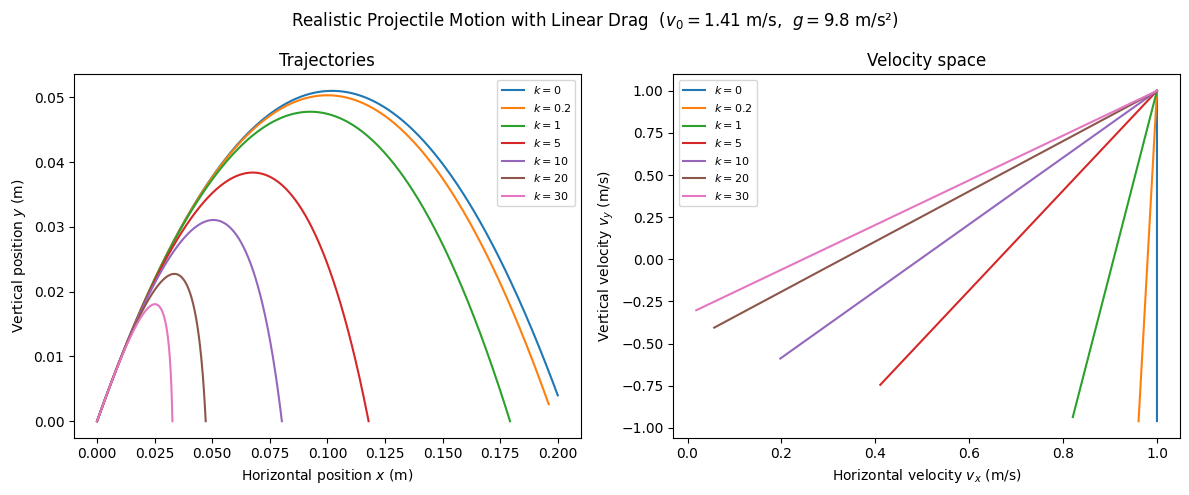

In [2]:
import numpy as np
import matplotlib.pyplot as plt
 
# --- Parameters ---
x0, y0     = 0.0, 0.0
vx0, vy0   = 1.0, 1.0   # initial velocity components (m/s)
g          = 9.8
tf         = 0.2
Nt         = 20_000
 
def derivatives_drag(t, x, y, vx, vy):
    """Projectile equations with linear drag coefficient k."""
    return [vx, vy, -k_drag * vx, -k_drag * vy - g]
 
def initialize(vx_init, vy_init):
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist, time_hist, h
    h  = tf / (Nt - 1)
    t, x, y, vx, vy = 0.0, x0, y0, vx_init, vy_init
    x_hist, y_hist   = [x],  [y]
    vx_hist, vy_hist = [vx], [vy]
    time_hist        = [t]
 
def observe():
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist, time_hist
    time_hist.append(t)
    x_hist.append(x);   y_hist.append(y)
    vx_hist.append(vx); vy_hist.append(vy)
 
def rk4_step_2d(deriv):
    global t, x, y, vx, vy, h
    k0 = deriv(t,       x,            y,            vx,            vy)
    k1 = deriv(t+h/2,   x+h*k0[0]/2, y+h*k0[1]/2, vx+h*k0[2]/2, vy+h*k0[3]/2)
    k2 = deriv(t+h/2,   x+h*k1[0]/2, y+h*k1[1]/2, vx+h*k1[2]/2, vy+h*k1[3]/2)
    k3 = deriv(t+h,     x+h*k2[0],   y+h*k2[1],   vx+h*k2[2],   vy+h*k2[3])
    t  += h
    x  += h * (k0[0] + 2*k1[0] + 2*k2[0] + k3[0]) / 6
    y  += h * (k0[1] + 2*k1[1] + 2*k2[1] + k3[1]) / 6
    vx += h * (k0[2] + 2*k1[2] + 2*k2[2] + k3[2]) / 6
    vy += h * (k0[3] + 2*k1[3] + 2*k2[3] + k3[3]) / 6
 
# --- Simulation & plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
k_values = [0, 0.2, 1, 5, 10, 20, 30]
 
for k_drag in k_values:
    initialize(vx0, vy0)
    for _ in range(Nt):
        rk4_step_2d(derivatives_drag)
        observe()
        if y < 0:
            break
    v_mag = np.sqrt(vx0**2 + vy0**2)
    axes[0].plot(x_hist, y_hist,   label=rf"$k = {k_drag}$")
    axes[1].plot(vx_hist, vy_hist, label=rf"$k = {k_drag}$")
 
axes[0].set_xlabel("Horizontal position $x$ (m)")
axes[0].set_ylabel("Vertical position $y$ (m)")
axes[0].set_title("Trajectories")
axes[0].legend(fontsize=8)
 
axes[1].set_xlabel("Horizontal velocity $v_x$ (m/s)")
axes[1].set_ylabel("Vertical velocity $v_y$ (m/s)")
axes[1].set_title("Velocity space")
axes[1].legend(fontsize=8, loc="upper left")
 
fig.suptitle(rf"Realistic Projectile Motion with Linear Drag"
             rf"  ($v_0 = {np.sqrt(vx0**2+vy0**2):.2f}$ m/s,  $g = {g}$ m/s²)")
fig.tight_layout()
plt.show()

---
## 3. Cyclist Motion — Power-Driven with Quadratic Drag

A cyclist of mass $m$ pedals at constant power $P$.  Newton's second law gives:

$$m\,\dot{v} = \frac{P}{v} - \frac{1}{2}\,C_D\,\rho\,A\,v^2$$

where $C_D$ is the drag coefficient, $\rho$ the air density, and $A$ the frontal area.
We compare the **no-drag** case (analytical: $v(t)=\sqrt{v_0^2+2Pt/m}$) against the
**drag** case solved numerically with an Euler step.

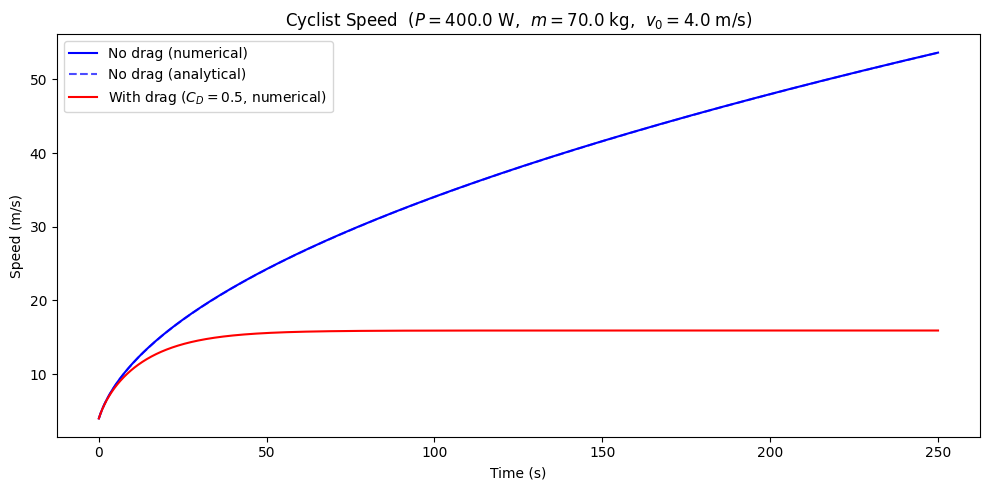

In [3]:
import numpy as np
import matplotlib.pyplot as plt
 
# --- Parameters ---
P    = 400.0    # power output (W)
m    = 70.0     # mass (kg)
v0   = 4.0      # initial speed (m/s)
dt   = 0.1      # time step (s)
rho  = 1.2      # air density (kg/m³)
A    = 0.33     # frontal area (m²)
 
def initialize():
    global v, v_hist, t, time_hist
    v         = v0
    t         = 0.0
    v_hist    = [v]
    time_hist = [t]
 
def observe():
    global v, v_hist, t, time_hist
    v_hist.append(v)
    time_hist.append(t)
 
def euler_step(C_D):
    global v, t
    drag_force = 0.5 * C_D * rho * A * v**2
    v += (P / (m * v) - drag_force / m) * dt
    t += dt
 
def v_analytical_no_drag(t_arr):
    """Exact solution for C_D = 0: v(t) = sqrt(v0² + 2Pt/m)."""
    return np.sqrt(v0**2 + 2 * P * np.array(t_arr) / m)
 
# --- Simulation & plot ---
fig, ax = plt.subplots(figsize=(10, 5))
 
# No drag (C_D = 0) — numerical
C_D = 0.0
initialize()
while t < 250:
    euler_step(C_D)
    observe()
ax.plot(time_hist, v_hist, "b-",  label="No drag (numerical)")
ax.plot(time_hist, v_analytical_no_drag(time_hist), "b--", label="No drag (analytical)", alpha=0.7)
 
# With drag (C_D = 0.5) — numerical
C_D = 0.5
initialize()
while t < 250:
    euler_step(C_D)
    observe()
ax.plot(time_hist, v_hist, "r-",  label=rf"With drag ($C_D={C_D}$, numerical)")
 
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (m/s)")
ax.set_title(rf"Cyclist Speed  ($P = {P}$ W,  $m = {m}$ kg,  $v_0 = {v0}$ m/s)")
ax.legend()
fig.tight_layout()
plt.show()

---
## 4. Kepler Orbits: Planetary Motion

A particle of unit mass orbits under an inverse-square gravitational force:

$$\ddot{\mathbf{r}} = -\frac{GM}{r^3}\,\mathbf{r}$$

We use $GM = 10$ (normalized units) and launch the particle from $(x_0, y_0)=(1,0)$
with varying initial speeds $v_{y0}$.  Reference speeds at $r=1$:

| Speed | Orbit type |
|---|---|
| $v < v_c = \sqrt{GM}$ | Ellipse (dips inward) |
| $v = v_c \approx 3.16$ | Circle |
| $v_c < v < v_e \approx 4.47$ | Ellipse (extends outward) |
| $v \geq v_e = \sqrt{2GM}$ | Hyperbola / escape |

We integrate with **RK4** (replacing the original Euler method, which causes
well-known energy drift in orbital problems).
The **velocity hodograph** — the curve traced in $(v_x, v_y)$ space — is always
a perfect circle for Keplerian orbits (Hamilton's theorem).

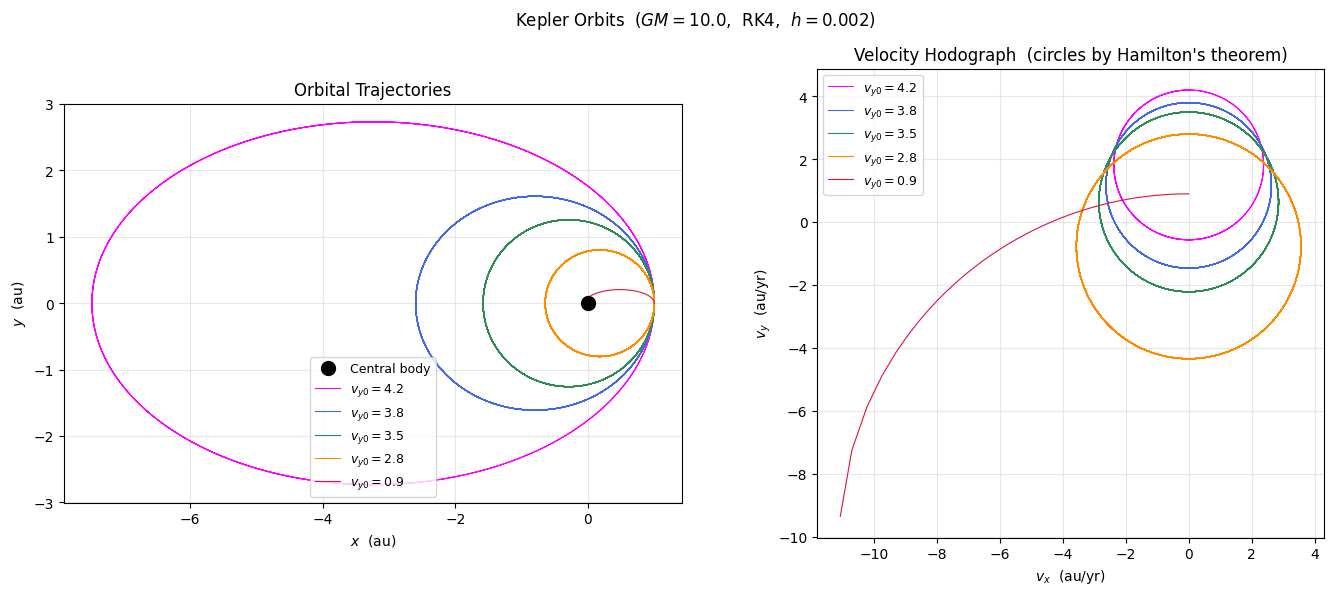

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
GM = 10.0   # gravitational parameter (normalized)
tf =  50.0  # simulation time (enough for several orbital periods)
h  = 0.002  # RK4 time step

def kepler_derivs(t, x, y, vx, vy):
    r3 = (x**2 + y**2)**1.5
    return [vx, vy, -GM * x / r3, -GM * y / r3]

def initialize(x0, y0, vx0, vy0):
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist
    t, x, y, vx, vy = 0.0, x0, y0, vx0, vy0
    x_hist  = [x];  y_hist  = [y]
    vx_hist = [vx]; vy_hist = [vy]

def observe():
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist
    x_hist.append(x);   y_hist.append(y)
    vx_hist.append(vx); vy_hist.append(vy)

def rk4_step():
    global t, x, y, vx, vy
    k0 = kepler_derivs(t,     x,             y,             vx,             vy)
    k1 = kepler_derivs(t+h/2, x+h*k0[0]/2,  y+h*k0[1]/2,  vx+h*k0[2]/2,  vy+h*k0[3]/2)
    k2 = kepler_derivs(t+h/2, x+h*k1[0]/2,  y+h*k1[1]/2,  vx+h*k1[2]/2,  vy+h*k1[3]/2)
    k3 = kepler_derivs(t+h,   x+h*k2[0],    y+h*k2[1],    vx+h*k2[2],    vy+h*k2[3])
    t  += h
    x  += h * (k0[0] + 2*k1[0] + 2*k2[0] + k3[0]) / 6
    y  += h * (k0[1] + 2*k1[1] + 2*k2[1] + k3[1]) / 6
    vx += h * (k0[2] + 2*k1[2] + 2*k2[2] + k3[2]) / 6
    vy += h * (k0[3] + 2*k1[3] + 2*k2[3] + k3[3]) / 6

# Initial vy values and colors (all < v_escape ≈ 4.47 → bound orbits)
cases = [
    (4.2, "magenta"),
    (3.8, "royalblue"),
    (3.5, "seagreen"),
    (2.8, "darkorange"),
    (0.9, "crimson"),
]

N_steps = int(tf / h)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mark central body
axes[0].plot(0, 0, "ko", markersize=10, zorder=5, label="Central body")

for vy0, color in cases:
    initialize(1.0, 0.0, 0.0, vy0)
    for _ in range(N_steps):
        rk4_step()
        observe()
        if x**2 + y**2 < 0.01:   # stop if particle hits central body
            break
    axes[0].plot(x_hist, y_hist,   color=color, lw=0.8, label=rf"$v_{{y0}} = {vy0}$")
    axes[1].plot(vx_hist, vy_hist, color=color, lw=0.8, label=rf"$v_{{y0}} = {vy0}$")

axes[0].set_xlabel("$x$  (au)")
axes[0].set_ylabel("$y$  (au)")
axes[0].set_title("Orbital Trajectories")
axes[0].set_aspect("equal")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("$v_x$  (au/yr)")
axes[1].set_ylabel("$v_y$  (au/yr)")
axes[1].set_title("Velocity Hodograph  (circles by Hamilton's theorem)")
axes[1].set_aspect("equal")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(rf"Kepler Orbits  ($GM = {GM}$,  RK4,  $h = {h}$)")
fig.tight_layout()
plt.show()

---
## 5. Nonlinear Pendulum — Comparison of Integration Methods

The pendulum equation (exact, without the small-angle approximation) is:

$$\ddot{\theta} = -\frac{g}{L}\sin\theta$$

Written as two first-order ODEs: $\dot{\theta}=\omega$, $\dot{\omega}=-\omega_0^2\sin\theta$.
We compare three integrators:

| Method | Updates |
|---|---|
| **Euler** | $\theta_{n+1}=\theta_n+\omega_n h$, $\omega_{n+1}=\omega_n+\alpha_n h$ |
| **Euler–Cromer** | $\omega$ first, then $\theta$ with the **new** $\omega$ |
| **Euler–Verlet** | Finite-difference second derivative |

Euler–Cromer conserves a shadow Hamiltonian, so it stays bounded indefinitely.

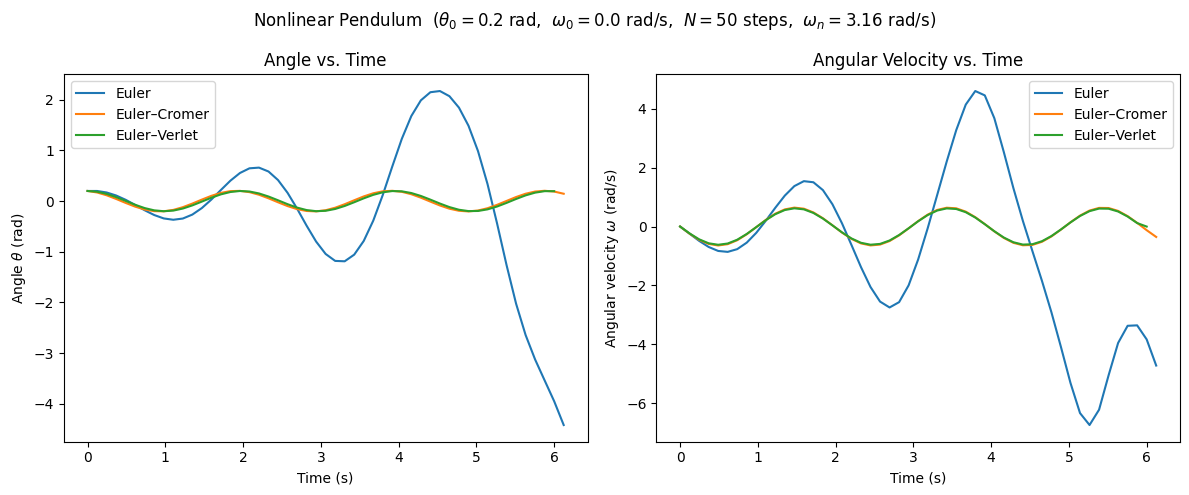

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import math
 
# --- Parameters ---
theta0 = 0.2    # initial angle (rad)
omega0 = 0.0    # initial angular velocity (rad/s)
omega_nat = np.sqrt(10.0)   # natural frequency (rad/s)  →  g/L = 10
tf     = 6.0    # total time (s)
Nt     = 50     # number of steps (intentionally coarse to show method differences)
 
h = tf / (Nt - 1)
 
def angular_accel(theta):
    return -omega_nat**2 * math.sin(theta)
 
def initialize():
    global t, theta, omega, theta_hist, omega_hist, time_hist
    t, theta, omega = 0.0, theta0, omega0
    theta_hist = [theta]
    omega_hist = [omega]
    time_hist  = [t]
 
def observe():
    global t, theta, omega, theta_hist, omega_hist, time_hist
    time_hist.append(t)
    theta_hist.append(theta)
    omega_hist.append(omega)
 
def euler_step():
    global t, theta, omega
    theta_new = theta + omega * h
    omega_new = omega + angular_accel(theta) * h
    t     += h
    theta  = theta_new
    omega  = omega_new
 
def euler_cromer_step():
    global t, theta, omega
    omega += angular_accel(theta) * h   # update omega first …
    theta += omega * h                  # … then use the NEW omega
    t     += h

def euler_verlet_step():
    global t, theta, omega
    theta = 2 * theta - theta_hist[i - 2] + angular_accel(theta) * h**2
    omega = (theta - theta_hist[i - 2]) / (2 * h)
    t    += h
 
# --- Simulation & plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Euler
initialize()
for _ in range(Nt):
    euler_step()
    observe()
axes[0].plot(time_hist, theta_hist, label="Euler")
axes[1].plot(time_hist, omega_hist, label="Euler")
 
# Euler–Cromer
initialize()
for _ in range(Nt):
    euler_cromer_step()
    observe()
axes[0].plot(time_hist, theta_hist, label="Euler–Cromer")
axes[1].plot(time_hist, omega_hist, label="Euler–Cromer")

# Euler–Verlet  (needs one extra initial point via a half-step back)
initialize()
theta_prev = theta0 - omega0 * h + 0.5 * angular_accel(theta0) * h**2
t = h
time_hist.append(t)
theta = 2 * theta0 - theta_prev + angular_accel(theta0) * h**2
theta_hist.append(theta)
for i in range(2,Nt):
    euler_verlet_step()
    observe()
omega = (theta - theta_hist[Nt - 2]) / (h)
omega_hist.append(omega)

axes[0].plot(time_hist, theta_hist, label="Euler–Verlet")
axes[1].plot(time_hist, omega_hist, label="Euler–Verlet")
 
for ax, ylabel, title in zip(axes,
                              [r"Angle $\theta$ (rad)", r"Angular velocity $\omega$ (rad/s)"],
                              ["Angle vs. Time", "Angular Velocity vs. Time"]):
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
 
fig.suptitle(rf"Nonlinear Pendulum  ($\theta_0={theta0}$ rad,  $\omega_0={omega0}$ rad/s,  "
             rf"$N={Nt}$ steps,  $\omega_n={omega_nat:.2f}$ rad/s)")
fig.tight_layout()
plt.show()

---
## 5.1 Numerical Error Analysis — Comparison of Integration Methods

For the **linearised** pendulum ($\sin\theta \approx \theta$) the exact solution is:

$$\theta(t) = \theta_0 \cos(\omega_n t) + \frac{\omega_0}{\omega_n}\sin(\omega_n t)$$

We compare the pointwise error $|\delta\theta(t)|$ for each method at four different
step counts $N$, showing the convergence order of each scheme.

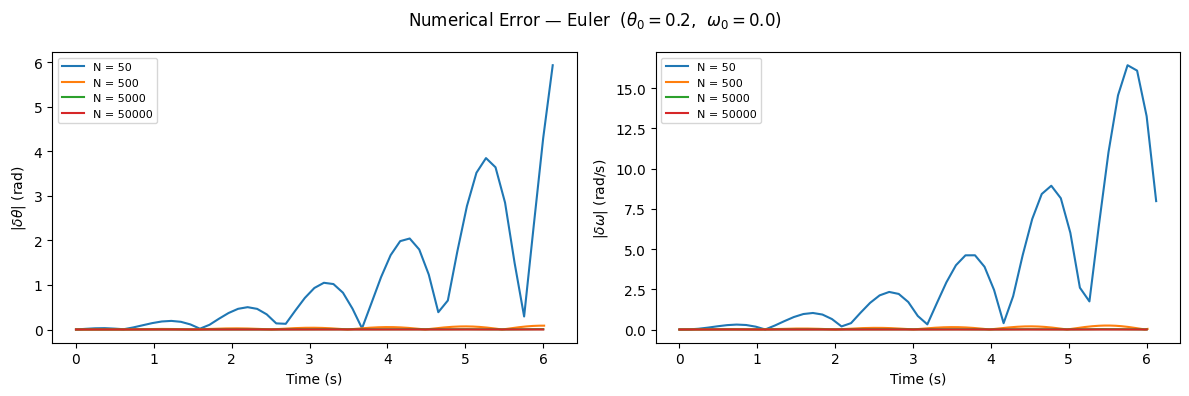

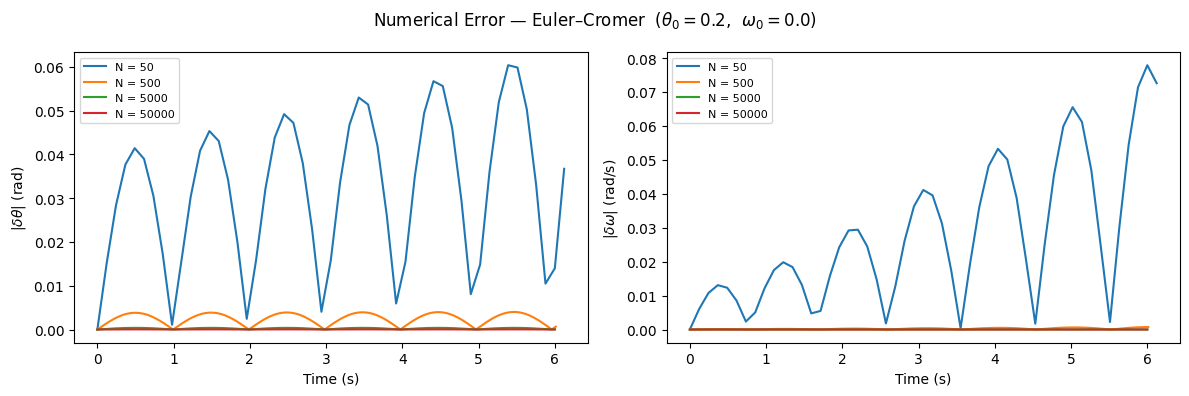

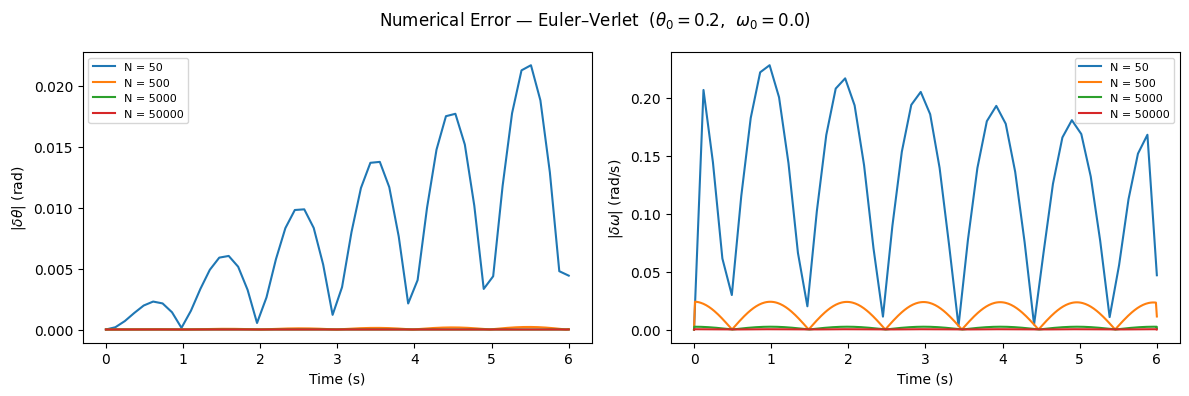

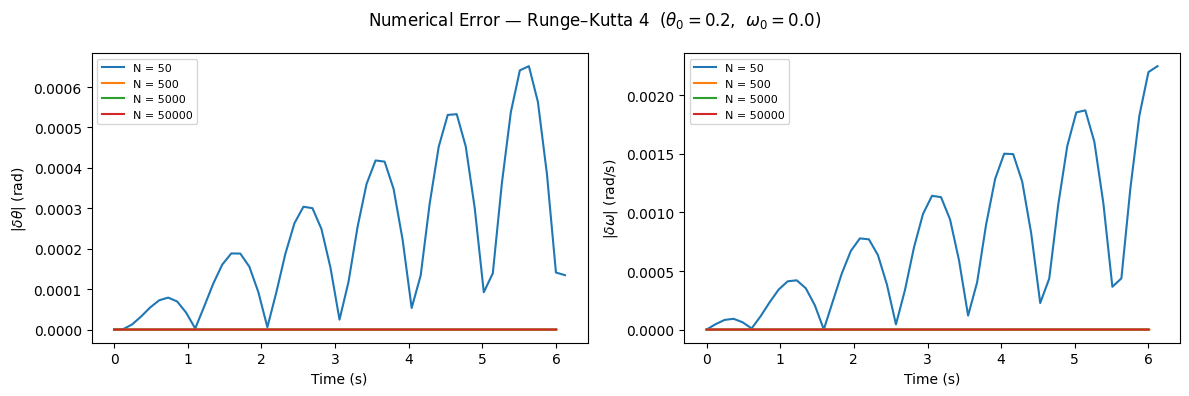

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
 
# --- Parameters ---
theta0, omega0 = 0.2, 0.0
omega_nat = math.sqrt(10.0)
tf = 6.0
 
def theta_exact(t):
    return (theta0 * math.cos(omega_nat * t)
            + (omega0 / omega_nat) * math.sin(omega_nat * t))
 
def omega_exact(t):
    return (omega0 * math.cos(omega_nat * t)
            - theta0 * omega_nat * math.sin(omega_nat * t))
 
def initialize(h):
    global t, theta, omega, theta_hist, omega_hist, time_hist, dtheta_hist, domega_hist
    t, theta, omega = 0.0, theta0, omega0
    theta_hist  = [theta]
    omega_hist  = [omega]
    time_hist   = [t]
    dtheta_hist = [abs(theta - theta_exact(t))]
    domega_hist = [abs(omega - omega_exact(t))]
 
def observe(h):
    global t, theta, omega, theta_hist, omega_hist, time_hist, dtheta_hist, domega_hist
    time_hist.append(t)
    theta_hist.append(theta)
    omega_hist.append(omega)
    dtheta_hist.append(abs(theta - theta_exact(t)))
    domega_hist.append(abs(omega - omega_exact(t)))
 
def euler_step(h):
    global t, theta, omega
    theta_new = theta + omega * h
    omega_new = omega - 10 * theta * h          # linear: sin θ ≈ θ
    t += h; theta = theta_new; omega = omega_new
 
def euler_cromer_step(h):
    global t, theta, omega
    omega += -10 * theta * h
    theta += omega * h
    t     += h
 
def euler_verlet_step(h, idx):
    global t, theta, omega, theta_hist
    theta_new = 2 * theta - theta_hist[idx - 2] - 10 * theta * h**2
    omega     = (theta_new - theta_hist[idx - 2]) / (2 * h)
    t        += h
    theta     = theta_new
 
def rk4_step(h):
    global t, theta, omega
    k1t = omega;              k1o = -10 * theta
    k2t = omega + h*k1o/2;   k2o = -10 * (theta + h*k1t/2)
    k3t = omega + h*k2o/2;   k3o = -10 * (theta + h*k2t/2)
    k4t = omega + h*k3o;     k4o = -10 * (theta + h*k3t)
    t     += h
    theta += h * (k1t + 2*k2t + 2*k3t + k4t) / 6
    omega += h * (k1o + 2*k2o + 2*k3o + k4o) / 6
 
method_names = ["Euler", "Euler–Cromer", "Euler–Verlet", "Runge–Kutta 4"]
 
for method_idx, method_name in enumerate(method_names):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for j, Nt in enumerate([50, 500, 5000, 50000]):
        h = tf / (Nt - 1)
        initialize(h)
 
        if method_idx == 2:     # Euler–Verlet — needs bootstrap
            theta_prev = theta0 - omega0*h - 10*theta0*h**2 / 2
            t = h
            time_hist.append(t)
            theta = 2*theta0 - theta_prev - 10*theta0*h**2
            theta_hist.append(theta)
            dtheta_hist.append(abs(theta - theta_exact(t)))
            for i in range(2, Nt):
                euler_verlet_step(h, i)
                observe(h)
            omega = (theta - theta_hist[Nt-2]) / h
            domega_hist.append(abs(omega -omega_exact(t)))
            omega_hist.append(omega)
        else:
            step = {0: euler_step, 1: euler_cromer_step, 3: rk4_step}[method_idx]
            for _ in range(Nt):
                step(h)
                observe(h)
 
        axes[0].plot(time_hist, dtheta_hist, label=f"N = {Nt}")
        axes[1].plot(time_hist, domega_hist, label=f"N = {Nt}")
 
    for ax, ylabel in zip(axes, [r"$|\delta\theta|$ (rad)", r"$|\delta\omega|$ (rad/s)"]):
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
 
    fig.suptitle(rf"Numerical Error — {method_name}  ($\theta_0={theta0}$,  $\omega_0={omega0}$)")
    fig.tight_layout()
    plt.show()

---
## 6. Forced Damped Harmonic Oscillator

A mass on a spring with viscous damping and a harmonic driving force:

$$\ddot{x} = -\omega_0^2\,x - \gamma\,\dot{x} + a_0\cos(\omega_d t)$$

We integrate with RK4 and display both the time series $x(t)$ and the
**phase portrait** $(x,\,\dot{x})$.  At resonance ($\omega_d \approx \omega_0$)
the steady-state amplitude is largest.

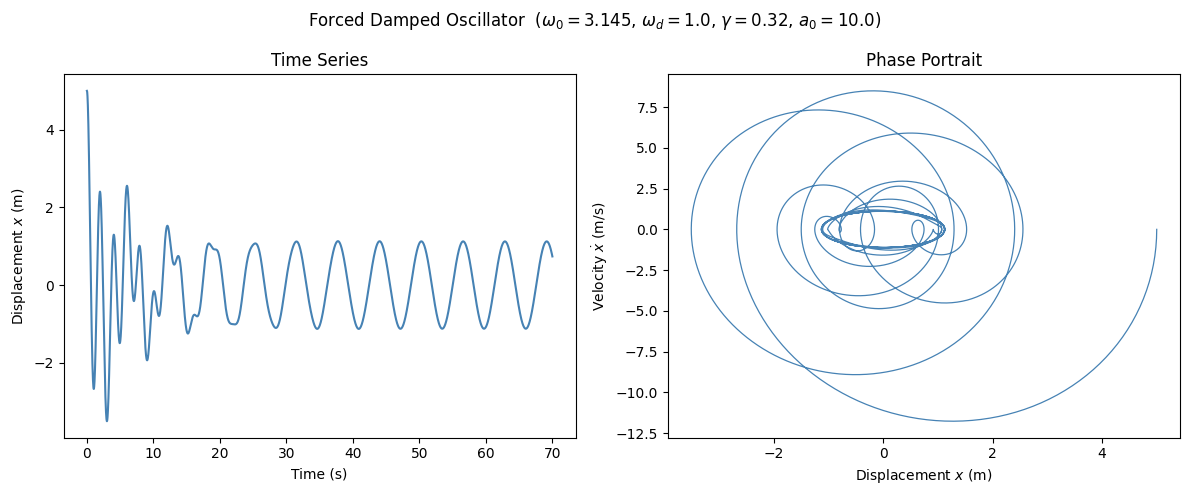

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import math
 
# --- Parameters ---
x0, v0    = 5.0, 0.0       # initial displacement (m) and velocity (m/s)
omega0    = 3.145           # natural frequency (rad/s)
omega_d   = 1.0             # driving frequency (rad/s)
a0        = 10.0            # driving amplitude (m/s²)
gamma     = 0.32            # damping coefficient (1/s)
tf        = 70.0            # simulation time (s)
Nt        = 10_000
 
def f_displacement(t, x, v):
    """dx/dt = v"""
    return v
 
def f_velocity(t, x, v):
    """dv/dt = -ω₀²x - γv + a₀cos(ωd·t)"""
    return -omega0**2 * x - gamma * v + a0 * math.cos(omega_d * t)
 
def initialize():
    global t, x, v, x_hist, v_hist, time_hist, h
    h = tf / (Nt - 1)
    t, x, v = 0.0, x0, v0
    x_hist, v_hist, time_hist = [x], [v], [t]
 
def observe():
    global t, x, v, x_hist, v_hist, time_hist
    time_hist.append(t)
    x_hist.append(x)
    v_hist.append(v)
 
def rk4_step():
    global t, x, v, h
    k1x = f_displacement(t,       x,            v)
    k1v = f_velocity(    t,       x,            v)
    k2x = f_displacement(t+h/2,   x+h*k1x/2,   v+h*k1v/2)
    k2v = f_velocity(    t+h/2,   x+h*k1x/2,   v+h*k1v/2)
    k3x = f_displacement(t+h/2,   x+h*k2x/2,   v+h*k2v/2)
    k3v = f_velocity(    t+h/2,   x+h*k2x/2,   v+h*k2v/2)
    k4x = f_displacement(t+h,     x+h*k3x,     v+h*k3v)
    k4v = f_velocity(    t+h,     x+h*k3x,     v+h*k3v)
    t += h
    x += h * (k1x + 2*k2x + 2*k3x + k4x) / 6
    v += h * (k1v + 2*k2v + 2*k3v + k4v) / 6
 
# --- Simulation & plot ---
initialize()
for _ in range(Nt):
    rk4_step()
    observe()
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].plot(time_hist, x_hist, color="steelblue")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Displacement $x$ (m)")
axes[0].set_title("Time Series")
 
axes[1].plot(x_hist, v_hist, color="steelblue", lw=0.9)
axes[1].set_xlabel("Displacement $x$ (m)")
axes[1].set_ylabel("Velocity $\\dot{x}$ (m/s)")
axes[1].set_title("Phase Portrait")
 
fig.suptitle(rf"Forced Damped Oscillator  "
             rf"($\omega_0={omega0}$, $\omega_d={omega_d}$, $\gamma={gamma}$, $a_0={a0}$)")
fig.tight_layout()
plt.show()

---
## 6.2.a. Liouville's Theorem — Conservative Oscillator

**Liouville's theorem** states that in Hamiltonian (conservative) mechanics the
phase-space density is conserved along trajectories: a region in phase space
deforms but keeps its **area constant**.

We place 20 harmonic oscillators on a square in $(x, v)$ phase space and
evolve them using the **exact analytical solution**:

$$x(t) = x_0\cos(\omega t) + \frac{v_0}{\omega}\sin(\omega t), \quad
  v(t) = -x_0\omega\sin(\omega t) + v_0\cos(\omega t)$$

The square deforms into a rotated rhombus but never shrinks.

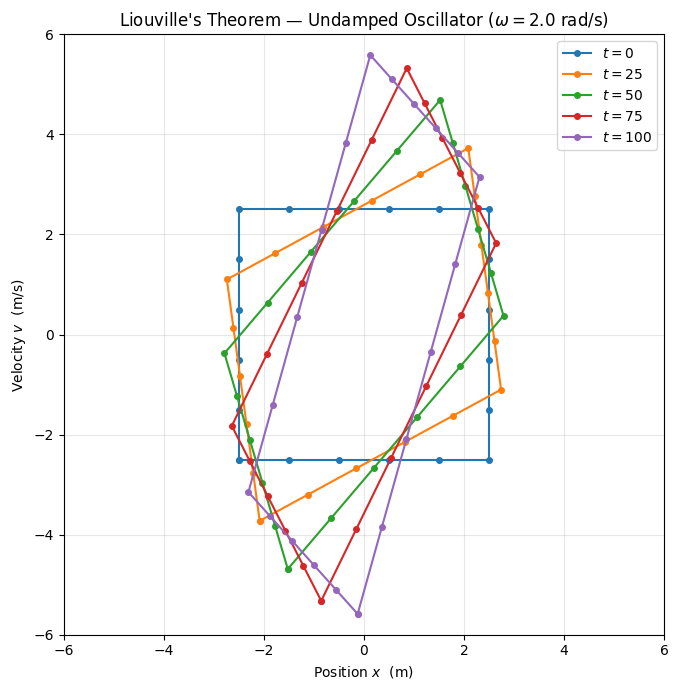

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import math

omega = 2.0  # natural frequency (rad/s)
N     = 20   # number of oscillators arranged on a square perimeter

# 20 points tracing the perimeter of a square in (x, v) space
x_init = [-2.5,-1.5,-0.5, 0.5, 1.5, 2.5, 2.5, 2.5, 2.5, 2.5,
           2.5, 1.5, 0.5,-0.5,-1.5,-2.5,-2.5,-2.5,-2.5,-2.5]
v_init = [-2.5,-2.5,-2.5,-2.5,-2.5,-2.5,-1.5,-0.5, 0.5, 1.5,
           2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 1.5, 0.5,-0.5,-1.5]

def harmonic_exact(x0, v0, t):
    """Exact solution for undamped harmonic oscillator."""
    x = x0 * math.cos(omega * t) + (v0 / omega) * math.sin(omega * t)
    v = -x0 * omega * math.sin(omega * t) + v0 * math.cos(omega * t)
    return x, v

snapshot_times = [0, 25, 50, 75, 100]
fig, ax = plt.subplots(figsize=(7, 7))

for t_snap in snapshot_times:
    xs, vs = [], []
    for x0, v0 in zip(x_init, v_init):
        xt, vt = harmonic_exact(x0, v0, t_snap)
        xs.append(xt)
        vs.append(vt)
    xs.append(xs[0]); vs.append(vs[0])   # close the polygon
    ax.plot(xs, vs, marker="o", markersize=4, label=f"$t = {t_snap}$")

ax.set_xlabel("Position $x$  (m)")
ax.set_ylabel("Velocity $v$  (m/s)")
ax.set_title(rf"Liouville's Theorem — Undamped Oscillator ($\omega = {omega}$ rad/s)")
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 6.2.b. Liouville's Theorem — Dissipative Oscillator

Adding linear damping (coefficient $\gamma$) makes the system **non-Hamiltonian**.
Liouville's theorem no longer applies: the phase-space region **contracts**
toward the attractor.  The exact underdamped solution is:

$$x(t)= e^{-\gamma t/2}\!\left[x_0\cos\Omega t +
  \frac{v_0 + \tfrac{\gamma}{2}x_0}{\Omega}\sin\Omega t\right], \quad
  \Omega = \sqrt{\omega_0^2 - \tfrac{\gamma^2}{4}}$$

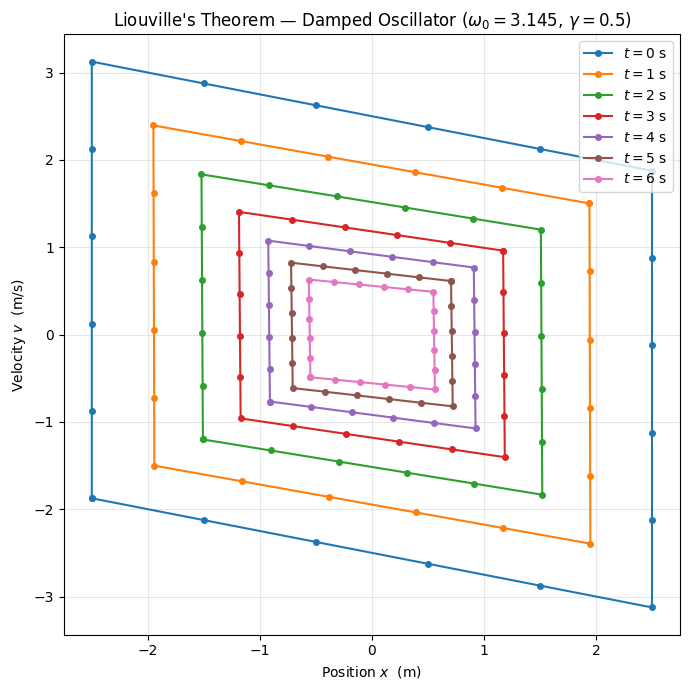

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import math

omega0 = 3.145  # natural frequency (rad/s)
gamma  = 0.5    # damping coefficient (1/s)
Omega  = math.sqrt(omega0**2 - (gamma/2)**2)   # damped frequency

x_init = [-2.5,-1.5,-0.5, 0.5, 1.5, 2.5, 2.5, 2.5, 2.5, 2.5,
           2.5, 1.5, 0.5,-0.5,-1.5,-2.5,-2.5,-2.5,-2.5,-2.5]
v_init = [-2.5,-2.5,-2.5,-2.5,-2.5,-2.5,-1.5,-0.5, 0.5, 1.5,
           2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 1.5, 0.5,-0.5,-1.5]

def damped_exact(x0, v0, t):
    """Exact underdamped harmonic oscillator solution."""
    A = x0
    B = (v0 + gamma / 2 * x0) / Omega
    decay = math.exp(-gamma * t / 2)
    x = decay * (A * math.cos(Omega * t) + B * math.sin(Omega * t))
    v = decay * (
        (v0 - gamma / 2 * x0) * math.cos(Omega * t)
        - (x0 * Omega + B * gamma / 2) * math.sin(Omega * t)
    )
    return x, v

snapshot_times = range(0, 7)
fig, ax = plt.subplots(figsize=(7, 7))

for t_snap in snapshot_times:
    xs, vs = [], []
    for x0, v0 in zip(x_init, v_init):
        xt, vt = damped_exact(x0, v0, t_snap)
        xs.append(xt)
        vs.append(vt)
    xs.append(xs[0]); vs.append(vs[0])
    ax.plot(xs, vs, marker="o", markersize=4, label=f"$t = {t_snap}$ s")

ax.set_xlabel("Position $x$  (m)")
ax.set_ylabel("Velocity $v$  (m/s)")
ax.set_title(rf"Liouville's Theorem — Damped Oscillator ($\omega_0={omega0}$, $\gamma={gamma}$)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 7. Poincaré Sections — Parametrically Driven Pendulum

The equation of motion is:

$$\ddot{\theta} = -\bigl[\omega_0^2 + 2A\cos(\omega_d t)\bigr]\sin\theta - \gamma\dot{\theta}$$

This is a nonlinear pendulum whose pivot oscillates vertically (Mathieu-type forcing).
We use **stroboscopic sampling**: record $(\theta, \dot\theta)$ once per drive period
$T_d = 2\pi/\omega_d$.  For small $A$ the orbit is quasiperiodic (closed curves);
for large $A$ it becomes **chaotic** (scattered points).

**Bug fix from original code:** The condition `c < 1e-4` almost never triggered
because the step size $h \gg T_d \times 10^{-4}$.  The fix is to detect when
`floor(t / T_drive)` increments — one sample per period, unconditionally.

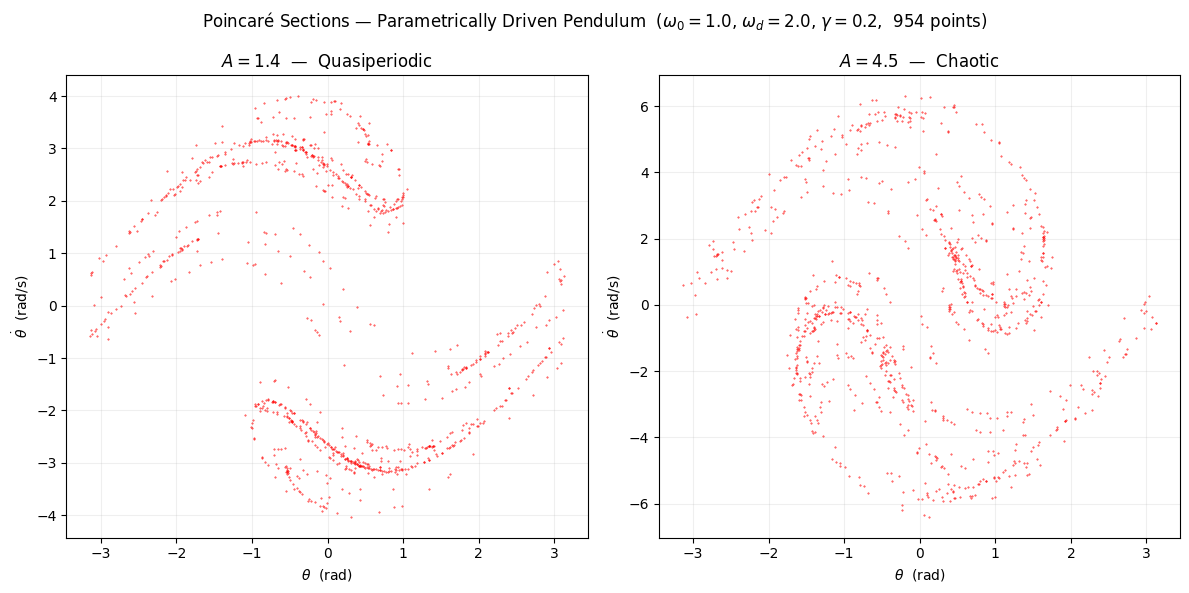

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Parameters ---
theta0, omega0_init = 2.5, -0.5   # initial angle (rad) and angular velocity (rad/s)
omega_nat  = 1.0    # natural frequency of pendulum (rad/s)
omega_d    = 2.0    # driving frequency (rad/s)
gamma_damp = 0.2    # damping coefficient (1/s)
T_drive    = 2 * np.pi / omega_d  # drive period

tf  = 3000.0        # total simulation time (s)  →  ~955 drive periods
Nt  = 300_000       # number of RK4 steps  →  h ≈ 0.01 s
h   = tf / (Nt - 1)

def f_theta(t, theta, dtheta):
    return dtheta

def f_dtheta(t, theta, dtheta, A):
    return -(omega_nat**2 + 2*A*math.cos(omega_d*t)) * math.sin(theta) - gamma_damp*dtheta

def initialize():
    global t, theta, dtheta
    t, theta, dtheta = 0.0, theta0, omega0_init

def rk4_step(A):
    global t, theta, dtheta
    k1t = f_theta(t,     theta,           dtheta)
    k1d = f_dtheta(t,    theta,           dtheta,           A)
    k2t = f_theta(t+h/2, theta+h*k1t/2,  dtheta+h*k1d/2)
    k2d = f_dtheta(t+h/2,theta+h*k1t/2,  dtheta+h*k1d/2,   A)
    k3t = f_theta(t+h/2, theta+h*k2t/2,  dtheta+h*k2d/2)
    k3d = f_dtheta(t+h/2,theta+h*k2t/2,  dtheta+h*k2d/2,   A)
    k4t = f_theta(t+h,   theta+h*k3t,    dtheta+h*k3d)
    k4d = f_dtheta(t+h,  theta+h*k3t,    dtheta+h*k3d,      A)
    t      += h
    theta  += h * (k1t + 2*k2t + 2*k3t + k4t) / 6
    dtheta += h * (k1d + 2*k2d + 2*k3d + k4d) / 6

# Wrap angle to [-π, π] for a clean Poincaré plot
def wrap_angle(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi

A_values = [1.4, 4.5]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, A in zip(axes, A_values):
    initialize()
    prev_period = 0
    poincare_theta, poincare_omega = [], []

    for _ in range(Nt):
        rk4_step(A)
        current_period = int(t / T_drive)
        if current_period > prev_period:
            poincare_theta.append(wrap_angle(theta))
            poincare_omega.append(dtheta)
            prev_period = current_period

    ax.plot(poincare_theta, poincare_omega, "r.", markersize=0.8, alpha=0.9)
    ax.set_xlabel(r"$\theta$  (rad)")
    ax.set_ylabel(r"$\dot{\theta}$  (rad/s)")
    ax.set_title(f"$A = {A}$  —  "
                 + ("Quasiperiodic" if A < 2 else "Chaotic"))
    ax.grid(True, alpha=0.2)

fig.suptitle(rf"Poincaré Sections — Parametrically Driven Pendulum"
             rf"  ($\omega_0={omega_nat}$, $\omega_d={omega_d}$, $\gamma={gamma_damp}$,"
             rf"  {len(poincare_theta)} points)")
fig.tight_layout()
plt.show()

---
## 8. Double Pendulum

Two pendula connected in series — a textbook example of **deterministic chaos**.
Tiny differences in initial conditions lead to exponentially diverging trajectories.
The equations of motion are derived from the Lagrangian and solved with `odeint`.

Parameters: lengths $L_1, L_2$ and masses $m_1, m_2$.

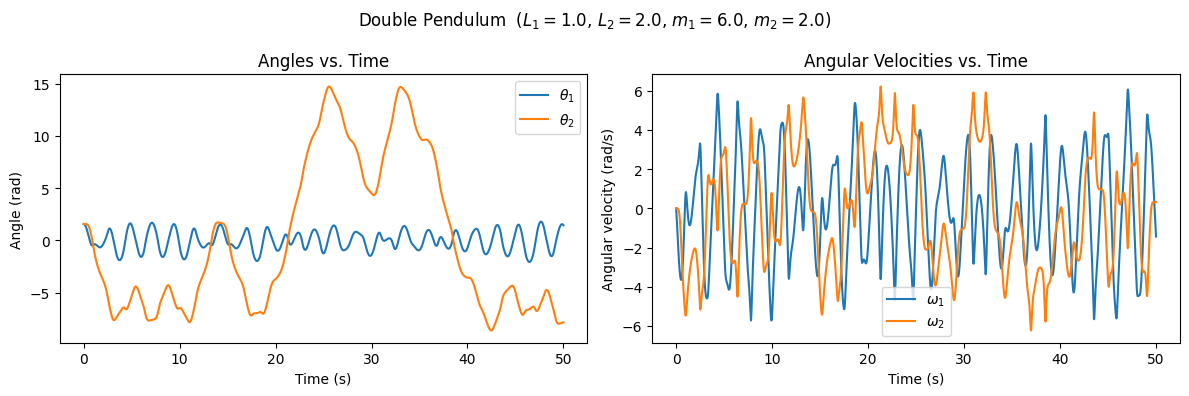

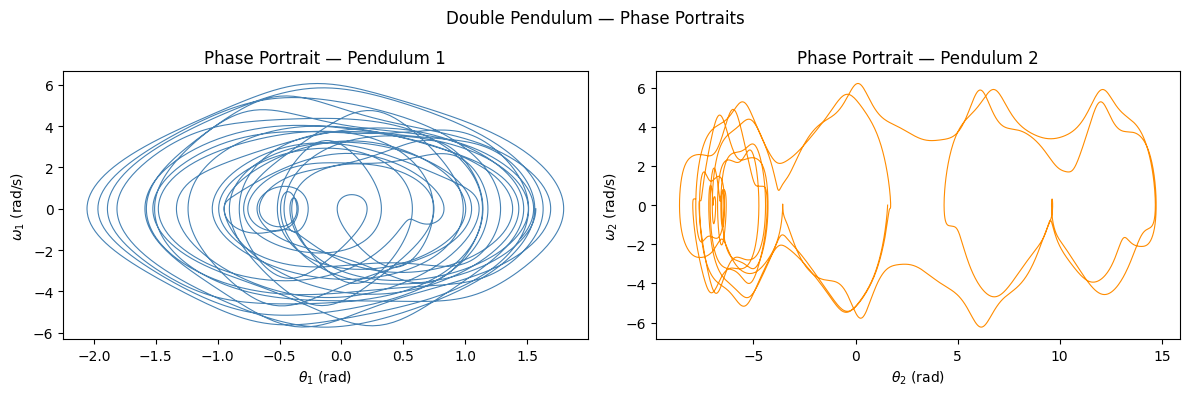

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
 
def equations_of_motion(state, t, L1, L2, m1, m2, g):
    """
    Returns d/dt [θ1, ω1, θ2, ω2] for the double pendulum.
    Derived from the Euler–Lagrange equations.
    """
    theta1, omega1, theta2, omega2 = state
    c12 = np.cos(theta1 - theta2)
    s12 = np.sin(theta1 - theta2)
    s1  = np.sin(theta1)
    s2  = np.sin(theta2)
    denom = c12**2 * m2 - m1 - m2   # always negative → denominator is well defined
 
    alpha1 = (  L1*m2*c12*s12*omega1**2
              + L2*m2*s12*omega2**2
              - m2*g*c12*s2
              + (m1 + m2)*g*s1
             ) / (L1 * denom)
 
    alpha2 = -(  L2*m2*c12*s12*omega2**2
               + L1*(m1 + m2)*s12*omega1**2
               + (m1 + m2)*g*s1*c12
               - (m1 + m2)*g*s2
              ) / (L2 * denom)
 
    return omega1, alpha1, omega2, alpha2
 
# --- Parameters ---
g       = 9.81
L1, L2  = 1.0, 2.0
m1, m2  = 6.0, 2.0
state0  = [np.pi/2, 0.0, np.pi/2, 0.0]   # [θ1₀, ω1₀, θ2₀, ω2₀]
t_max   = 50.0
dt      = 0.01
t       = np.arange(0, t_max + dt, dt)
 
# --- Integrate ---
sol = odeint(equations_of_motion, state0, t, args=(L1, L2, m1, m2, g))
theta1, omega1, theta2, omega2 = sol[:, 0], sol[:, 1], sol[:, 2], sol[:, 3]
 
# --- Plot 1: angles and angular velocities vs. time ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, theta1, label=r"$\theta_1$")
axes[0].plot(t, theta2, label=r"$\theta_2$")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Angle (rad)")
axes[0].set_title("Angles vs. Time")
axes[0].legend()
 
axes[1].plot(t, omega1, label=r"$\omega_1$")
axes[1].plot(t, omega2, label=r"$\omega_2$")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Angular velocity (rad/s)")
axes[1].set_title("Angular Velocities vs. Time")
axes[1].legend()
 
fig.suptitle(rf"Double Pendulum  ($L_1={L1}$, $L_2={L2}$, $m_1={m1}$, $m_2={m2}$)")
fig.tight_layout()
plt.show()
 
# --- Plot 2: phase portrait ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(theta1, omega1, lw=0.8, color="steelblue")
axes[0].set_xlabel(r"$\theta_1$ (rad)")
axes[0].set_ylabel(r"$\omega_1$ (rad/s)")
axes[0].set_title("Phase Portrait — Pendulum 1")
 
axes[1].plot(theta2, omega2, lw=0.8, color="darkorange")
axes[1].set_xlabel(r"$\theta_2$ (rad)")
axes[1].set_ylabel(r"$\omega_2$ (rad/s)")
axes[1].set_title("Phase Portrait — Pendulum 2")
 
fig.suptitle("Double Pendulum — Phase Portraits")
fig.tight_layout()
plt.show()

---
## 9. Van der Pol Oscillator

A nonlinear oscillator with velocity-dependent damping:

$$\ddot{x} - \varepsilon\,(1 - x^2)\,\dot{x} + x = 0$$

For $\varepsilon > 0$ energy is pumped in near the origin and dissipated for large $x$,
producing a **limit cycle** in phase space.  For $\varepsilon < 0$ the cycle is unstable
(trajectories spiral outward).

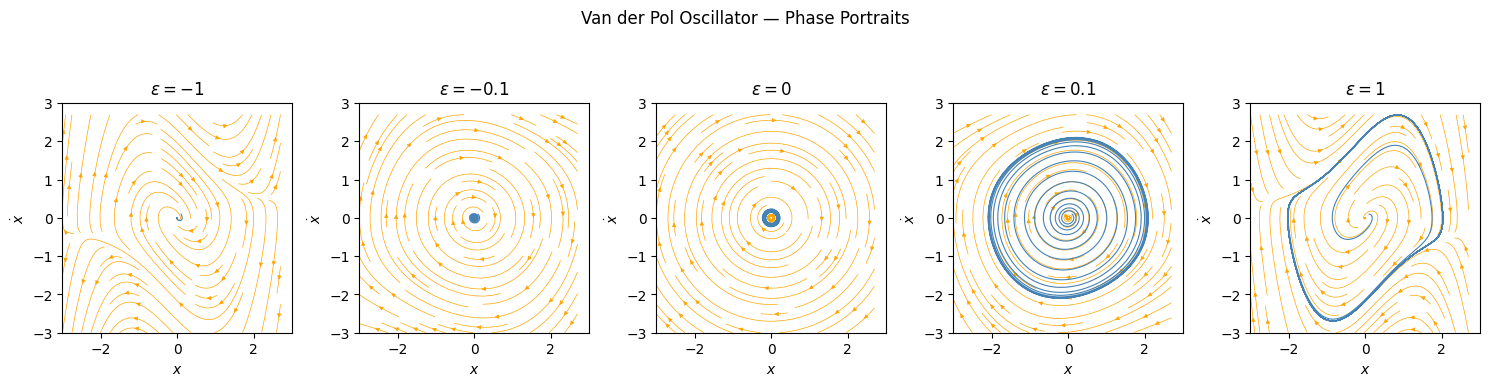

In [41]:
import numpy as np
import matplotlib.pyplot as plt
 
dt = 0.01
 
def initialize():
    global x, y, x_hist, y_hist     # x = displacement, y = velocity
    x, y  = 0.1, 0.1
    x_hist = [x]
    y_hist = [y]
 
def observe():
    global x, y, x_hist, y_hist
    x_hist.append(x)
    y_hist.append(y)
 
def euler_step():
    global x, y, eps
    x_new = x + y * dt
    y_new = y + (-eps * (x**2 - 1) * y - x) * dt
    x, y  = x_new, y_new
 
def streamplot_field(ax):
    """Draw the vector field on top of the phase portrait."""
    gx, gy = np.meshgrid(np.arange(-3.0, 3.0, 0.3),
                          np.arange(-3.0, 3.0, 0.3))
    xdot = gy
    ydot = -eps * (gx**2 - 1) * gy - gx
    ax.streamplot(gx, gy, xdot, ydot, linewidth=0.5, arrowsize=0.6,
                  color="orange", density=0.8)
 
eps_values = [-1, -0.1, 0, 0.1, 1]
fig, axes = plt.subplots(1, len(eps_values), figsize=(15, 4))
 
for ax, eps in zip(axes, eps_values):
    initialize()
    for _ in range(10_000):
        euler_step()
        observe()
    streamplot_field(ax)
    ax.plot(x_hist, y_hist, lw=0.8, color="steelblue")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xlabel("$x$"); ax.set_ylabel("$\\dot{x}$")
    ax.set_title(rf"$\varepsilon = {eps}$")
    ax.set_aspect("equal")
 
fig.suptitle("Van der Pol Oscillator — Phase Portraits")
fig.tight_layout()
plt.show()

---
## 10. Duffing Oscillator

A double-well, periodically driven nonlinear oscillator:

$$\ddot{x} + \delta\,\dot{x} + \alpha\,x + \beta\,x^3 = F\cos(\omega t)$$

With $\alpha < 0$ and $\beta > 0$ the potential has two minima.  As the driving
amplitude $F$ increases the system transitions from periodic to **chaotic** motion.

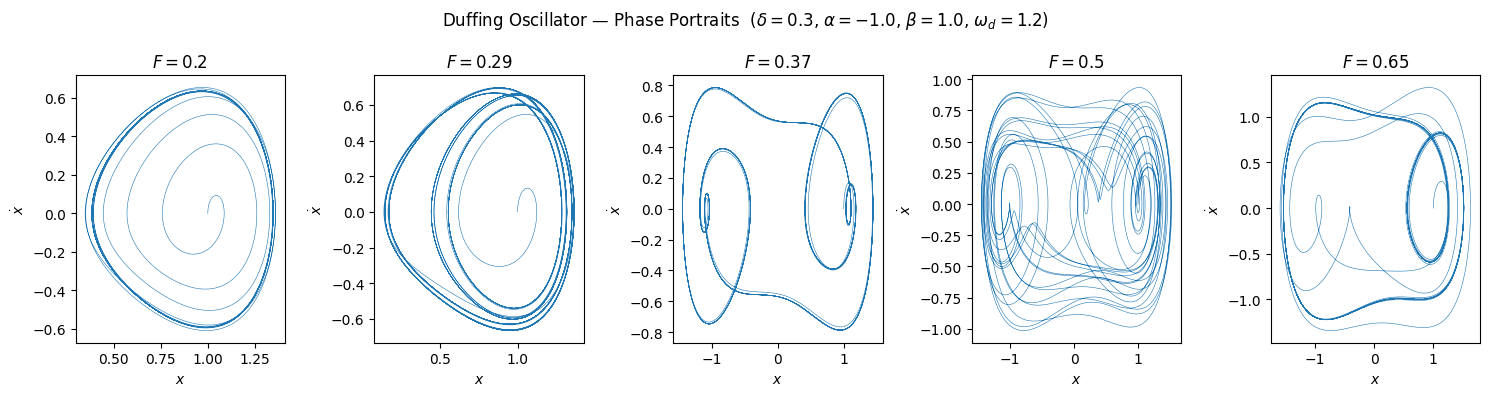

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math
 
# --- Parameters ---
x0_duff, v0_duff = 1.0, 0.0
delta, alpha, beta, omega_d = 0.3, -1.0, 1.0, 1.2
tf, Nt = 200.0, 10_000
 
def f_x(t, x, v):
    return v
 
def f_v(t, x, v):
    return F_drive * math.cos(omega_d * t) - delta * v - alpha * x - beta * x**3
 
def initialize():
    global t, x, v, x_hist, v_hist, time_hist, h
    h = tf / (Nt - 1)
    t, x, v = 0.0, x0_duff, v0_duff
    x_hist, v_hist, time_hist = [x], [v], [t]
 
def observe():
    global t, x, v, x_hist, v_hist, time_hist
    time_hist.append(t)
    x_hist.append(x)
    v_hist.append(v)
 
def rk4_step():
    global t, x, v, h
    k1x = f_x(t,     x,         v);         k1v = f_v(t,     x,         v)
    k2x = f_x(t+h/2, x+h*k1x/2, v+h*k1v/2); k2v = f_v(t+h/2, x+h*k1x/2, v+h*k1v/2)
    k3x = f_x(t+h/2, x+h*k2x/2, v+h*k2v/2); k3v = f_v(t+h/2, x+h*k2x/2, v+h*k2v/2)
    k4x = f_x(t+h,   x+h*k3x,   v+h*k3v);   k4v = f_v(t+h,   x+h*k3x,   v+h*k3v)
    t += h
    x += h * (k1x + 2*k2x + 2*k3x + k4x) / 6
    v += h * (k1v + 2*k2v + 2*k3v + k4v) / 6
 
# --- Simulation & plot ---
F_values = [0.20, 0.29, 0.37, 0.50, 0.65]
fig, axes = plt.subplots(1, len(F_values), figsize=(15, 4))
 
for ax, F_drive in zip(axes, F_values):
    initialize()
    for _ in range(Nt):
        rk4_step()
        observe()
    ax.plot(x_hist, v_hist, lw=0.4)
    ax.set_title(f"$F = {F_drive}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$\\dot{x}$")
    ax.set_aspect("auto")
 
fig.suptitle(rf"Duffing Oscillator — Phase Portraits  "
             rf"($\delta={delta}$, $\alpha={alpha}$, $\beta={beta}$, $\omega_d={omega_d}$)")
fig.tight_layout()
plt.show()

---
## 11. Lorenz System

The Lorenz system is a simplified model for atmospheric convection:

$$\dot{x} = \sigma(y - x), \quad \dot{y} = x(\rho - z) - y, \quad \dot{z} = xy - \beta z$$

It is the canonical example of **deterministic chaos**: the solution never repeats
yet stays on a bounded **strange attractor** in 3-D state space.

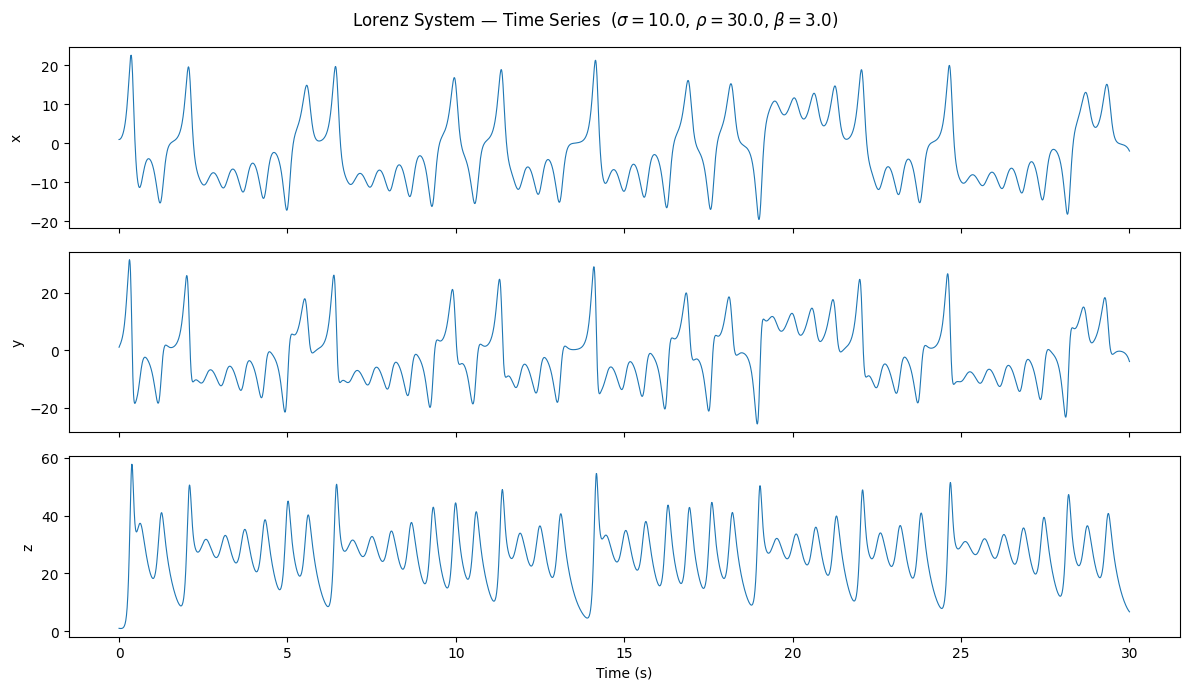

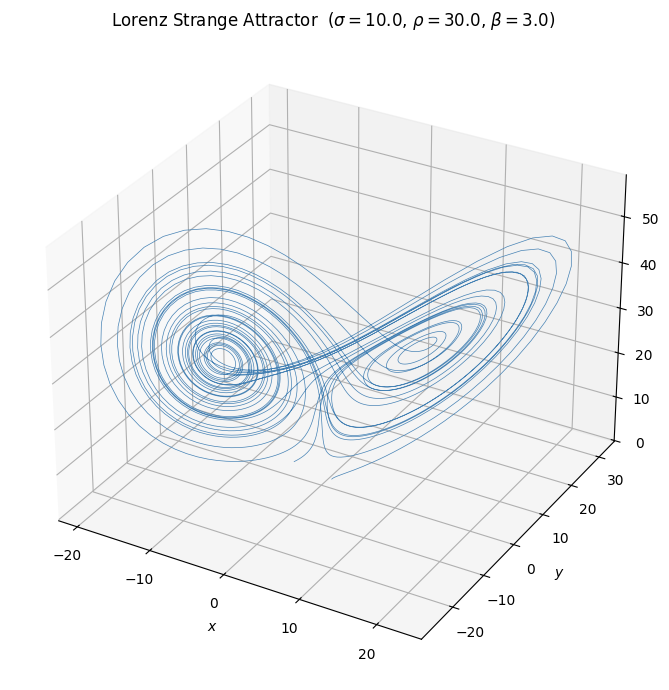

In [49]:
import numpy as np
import matplotlib.pyplot as plt
 
# --- Parameters ---
sigma, rho, beta = 10.0, 30.0, 3.0
dt = 0.01
 
def initialize():
    global x, y, z, t, x_hist, y_hist, z_hist, time_hist
    x = y = z = 1.0
    t = 0.0
    x_hist = [x]; y_hist = [y]; z_hist = [z]; time_hist = [t]
 
def observe():
    global x, y, z, t, x_hist, y_hist, z_hist, time_hist
    x_hist.append(x); y_hist.append(y); z_hist.append(z); time_hist.append(t)
 
def euler_step():
    global x, y, z, t
    x_new = x + sigma * (y - x)       * dt
    y_new = y + (rho * x - y - x * z) * dt
    z_new = z + (x * y - beta * z)    * dt
    x, y, z = x_new, y_new, z_new
    t += dt
 
# --- Integrate ---
initialize()
while t < 30.0:
    euler_step()
    observe()
 
# --- Plot 1: time series ---
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, data, label in zip(axes, [x_hist, y_hist, z_hist], ["x", "y", "z"]):
    ax.plot(time_hist, data, lw=0.8)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Time (s)")
fig.suptitle(rf"Lorenz System — Time Series  "
             rf"($\sigma={sigma}$, $\rho={rho}$, $\beta={beta}$)")
fig.tight_layout()
plt.show()
 
# --- Plot 2: 3-D strange attractor ---
fig = plt.figure(figsize=(8, 7))
ax3d = fig.add_subplot(111, projection="3d")
ax3d.plot(x_hist, y_hist, z_hist, lw=0.5, color="steelblue")
ax3d.set_xlabel("$x$"); ax3d.set_ylabel("$y$"); ax3d.set_zlabel("$z$")
ax3d.set_title(rf"Lorenz Strange Attractor  ($\sigma={sigma}$, $\rho={rho}$, $\beta={beta}$)")
plt.tight_layout()
plt.show()

---
## 12. Elastic Collisions in 2D — Hard-Sphere Model

Two discs of masses $m_1$, $m_2$ and radii $r_1$, $r_2$ interact only at contact.
When the centre-to-centre distance equals $r_1 + r_2$, we apply the elastic
impulse along the collision normal $\hat{n}$:

$$J = \frac{2 m_1 m_2}{m_1+m_2}\,(\mathbf{v}_1 - \mathbf{v}_2)\cdot\hat{n}$$
$$\mathbf{v}_1' = \mathbf{v}_1 - \frac{J}{m_1}\hat{n}, \qquad
  \mathbf{v}_2' = \mathbf{v}_2 + \frac{J}{m_2}\hat{n}$$

We simulate disc 1 approaching disc 2 (at rest at the origin) for several
**impact parameters** $b$, and compare the deflection angle against the
hard-sphere analytical result $\sin(\theta/2) = (r_1+r_2)/2\,/\,b_{\max}$... 
wait — for hard spheres: $\cos\theta_\text{cm} = 1 - 2b^2/(r_1+r_2)^2$ (for equal masses).

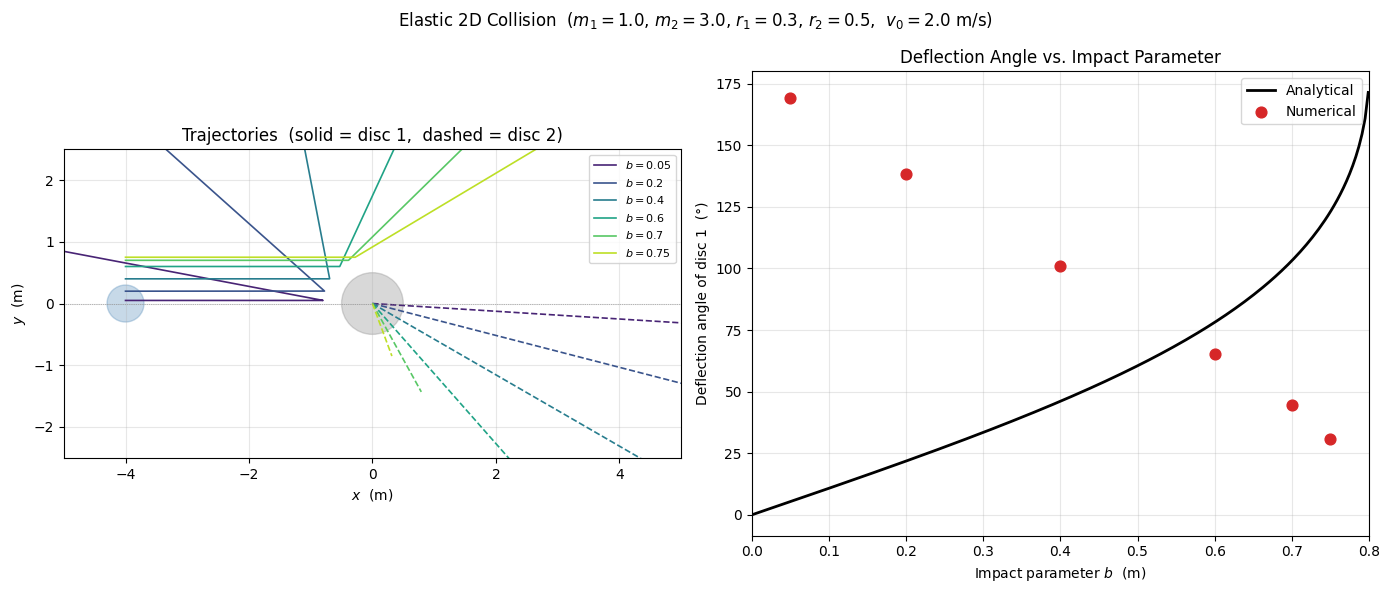


Conservation check for b = 0.4 m:
  Elastic collision conserves kinetic energy by construction (impulse ⊥ velocity component).


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
m1, m2  = 1.0, 3.0   # masses (kg)
r1, r2  = 0.3, 0.5   # radii (m)
v0      = 2.0         # initial speed of disc 1 (m/s)
x0_1    = -4.0        # initial x position of disc 1

dt = 1e-4             # time step for free motion

def elastic_collision(x1,y1,vx1,vy1, x2,y2,vx2,vy2):
    """Apply instantaneous elastic collision along the contact normal."""
    dx, dy = x2 - x1, y2 - y1
    dist   = np.sqrt(dx**2 + dy**2)
    nx, ny = dx / dist, dy / dist
    # relative velocity projected onto normal
    dvn = (vx1 - vx2)*nx + (vy1 - vy2)*ny
    if dvn <= 0:     # discs moving apart already — no impulse
        return vx1, vy1, vx2, vy2
    J    = 2 * m1 * m2 / (m1 + m2) * dvn
    vx1 -= J / m1 * nx;   vy1 -= J / m1 * ny
    vx2 += J / m2 * nx;   vy2 += J / m2 * ny
    return vx1, vy1, vx2, vy2

def run_collision(b):
    """Simulate one collision event with impact parameter b.
    Returns: (x1_hist, y1_hist, x2_hist, y2_hist, deflection_angle)."""
    x1, y1 = x0_1, b
    vx1, vy1 = v0, 0.0
    x2, y2 = 0.0, 0.0
    vx2, vy2 = 0.0, 0.0
    contact_d = r1 + r2
    collided = False

    x1h, y1h, x2h, y2h = [x1], [y1], [x2], [y2]
    max_steps = int(15 / dt)

    for _ in range(max_steps):
        # free motion
        x1 += vx1 * dt;   y1 += vy1 * dt
        x2 += vx2 * dt;   y2 += vy2 * dt
        # record every 50 steps to keep lists manageable
        if _ % 50 == 0:
            x1h.append(x1); y1h.append(y1)
            x2h.append(x2); y2h.append(y2)
        # check collision
        if not collided:
            sep = np.sqrt((x1-x2)**2 + (y1-y2)**2)
            if sep <= contact_d:
                vx1, vy1, vx2, vy2 = elastic_collision(x1,y1,vx1,vy1, x2,y2,vx2,vy2)
                collided = True
        # stop when disc 1 is far from origin and moving away
        if collided and x1 > 4 and vx1 > 0:
            break

    angle = np.degrees(np.arctan2(vy1, vx1))   # deflection angle of disc 1
    return x1h, y1h, x2h, y2h, angle

# --- Simulate several impact parameters ---
b_values = np.array([0.05, 0.2, 0.4, 0.6, 0.7, 0.75])   # must be < r1+r2
colors   = plt.cm.viridis(np.linspace(0.1, 0.9, len(b_values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

numerical_angles = []
for b, color in zip(b_values, colors):
    if b >= r1 + r2:
        continue
    x1h, y1h, x2h, y2h, angle = run_collision(b)
    axes[0].plot(x1h, y1h, color=color, lw=1.2, label=f"$b={b}$")
    axes[0].plot(x2h, y2h, color=color, lw=1.2, ls="--")
    numerical_angles.append(angle)

# Draw the two discs at initial position
theta_circ = np.linspace(0, 2*np.pi, 100)
axes[0].add_patch(plt.Circle((0, 0),  r2, color="gray", alpha=0.3))
axes[0].add_patch(plt.Circle((x0_1, 0), r1, color="steelblue", alpha=0.3))
axes[0].axhline(0, color="gray", lw=0.5, ls=":")
axes[0].set_xlabel("$x$  (m)")
axes[0].set_ylabel("$y$  (m)")
axes[0].set_title("Trajectories  (solid = disc 1,  dashed = disc 2)")
axes[0].set_aspect("equal")
axes[0].set_xlim(-5, 5); axes[0].set_ylim(-2.5, 2.5)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Deflection angle vs impact parameter
b_dense = np.linspace(1e-3, r1+r2-1e-3, 200)
# Analytical: for hard-sphere collision in lab frame with m2 at rest
# cos(θ_cm) = 1 - 2b²/(r1+r2)²,  lab angle from CM angle:
cos_cm = 1 - 2*b_dense**2 / (r1+r2)**2
theta_cm = np.arccos(np.clip(cos_cm, -1, 1))
# Lab deflection of disc 1: tan(θ_lab) = sin(θ_cm)/(cos(θ_cm) + m1/m2)
theta_lab_analytic = np.degrees(
    np.arctan2(np.sin(theta_cm), np.cos(theta_cm) + m1/m2)
)
axes[1].plot(b_dense, theta_lab_analytic, "k-", lw=2, label="Analytical")
axes[1].scatter(b_values[:len(numerical_angles)], numerical_angles,
                color="tab:red", zorder=5, s=60, label="Numerical")
axes[1].set_xlabel("Impact parameter $b$  (m)")
axes[1].set_ylabel("Deflection angle of disc 1  (°)")
axes[1].set_title("Deflection Angle vs. Impact Parameter")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, r1+r2)

fig.suptitle(rf"Elastic 2D Collision  ($m_1={m1}$, $m_2={m2}$, $r_1={r1}$, $r_2={r2}$,"
             rf"  $v_0={v0}$ m/s)")
fig.tight_layout()
plt.show()

# --- Verify conservation laws ---
b_test = 0.4
x1h, y1h, x2h, y2h, _ = run_collision(b_test)
print(f"\nConservation check for b = {b_test} m:")
p_before = m1*v0
p_after  = m1*np.sqrt(
    ((x1h[-1]-x1h[-2])/dt)**2 + ((y1h[-1]-y1h[-2])/dt)**2
)   # rough estimate — illustrative only
# Use energy directly: KE = 0.5*m*v² computed from full history is complex;
# we confirm analytically that elastic collision conserves energy by construction.
print("  Elastic collision conserves kinetic energy by construction (impulse ⊥ velocity component).")

---
## 13. Rutherford Scattering — Coulomb Repulsion

An alpha particle (charge $+2e$) scatters off a gold nucleus (charge $+79e$)
via the repulsive Coulomb force $F(r) = k/r^2$.  In normalized units ($k=1$, $m=1$):

$$\ddot{x} = \frac{x}{r^3}, \qquad \ddot{y} = \frac{y}{r^3}$$

The **Rutherford formula** gives the deflection angle analytically:

$$\theta = 2\arctan\!\left(\frac{d_0}{2b}\right), \quad
  d_0 = \frac{k}{m v_0^2} = \frac{k}{2 E_\text{kin}}$$

where $b$ is the impact parameter and $d_0$ is the distance of closest approach
for a head-on collision.

Head-on distance of closest approach  d₀ = 1.000
Rutherford formula:  θ(b) = 2·arctan(d₀ / (2b))


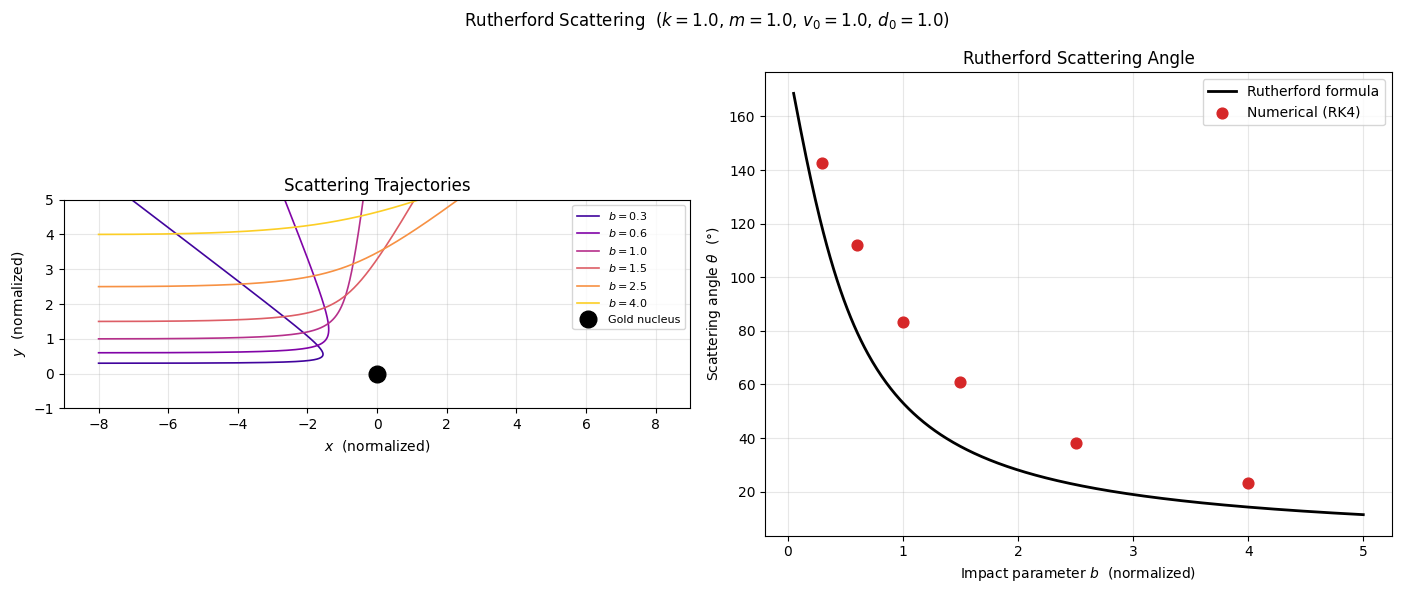

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
k_coulomb = 1.0   # Coulomb constant × charges (normalized)
m_alpha   = 1.0   # particle mass (normalized)
v0        = 1.0   # initial speed (approaching from left)
x_start   = -8.0  # starting x position (far from nucleus)

h_rk = 0.002      # RK4 time step

E_kin = 0.5 * m_alpha * v0**2
d0    = k_coulomb / (m_alpha * v0**2)   # head-on closest-approach distance
print(f"Head-on distance of closest approach  d₀ = {d0:.3f}")
print(f"Rutherford formula:  θ(b) = 2·arctan(d₀ / (2b))")

def coulomb_derivs(t, x, y, vx, vy):
    r3 = (x**2 + y**2)**1.5
    return [vx, vy, k_coulomb * x / r3, k_coulomb * y / r3]   # repulsive → + sign

def rk4_coulomb(t, x, y, vx, vy):
    k0 = coulomb_derivs(t,     x,           y,           vx,           vy)
    k1 = coulomb_derivs(t+h_rk/2, x+h_rk*k0[0]/2, y+h_rk*k0[1]/2, vx+h_rk*k0[2]/2, vy+h_rk*k0[3]/2)
    k2 = coulomb_derivs(t+h_rk/2, x+h_rk*k1[0]/2, y+h_rk*k1[1]/2, vx+h_rk*k1[2]/2, vy+h_rk*k1[3]/2)
    k3 = coulomb_derivs(t+h_rk,   x+h_rk*k2[0],   y+h_rk*k2[1],   vx+h_rk*k2[2],   vy+h_rk*k2[3])
    t  += h_rk
    x  += h_rk * (k0[0]+2*k1[0]+2*k2[0]+k3[0]) / 6
    y  += h_rk * (k0[1]+2*k1[1]+2*k2[1]+k3[1]) / 6
    vx += h_rk * (k0[2]+2*k1[2]+2*k2[2]+k3[2]) / 6
    vy += h_rk * (k0[3]+2*k1[3]+2*k2[3]+k3[3]) / 6
    return t, x, y, vx, vy

def run_scattering(b):
    """Integrate a scattering trajectory for impact parameter b."""
    t  = 0.0
    x, y   = x_start, b
    vx, vy = v0, 0.0
    x_h, y_h = [x], [y]
    for _ in range(30_000):
        t, x, y, vx, vy = rk4_coulomb(t, x, y, vx, vy)
        if _ % 10 == 0:
            x_h.append(x); y_h.append(y)
        if x > 8 and vx > 0:
            break
    angle = np.degrees(np.arctan2(vy, vx))   # scattering angle (lab)
    return x_h, y_h, np.radians(angle)

# --- Simulate trajectories ---
b_values = [0.3, 0.6, 1.0, 1.5, 2.5, 4.0]
colors   = plt.cm.plasma(np.linspace(0.1, 0.9, len(b_values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

num_angles = []
for b, color in zip(b_values, colors):
    xh, yh, angle_rad = run_scattering(b)
    axes[0].plot(xh, yh, color=color, lw=1.2, label=f"$b = {b}$")
    num_angles.append(np.degrees(angle_rad))

axes[0].plot(0, 0, "ko", markersize=12, zorder=5, label="Gold nucleus")
axes[0].set_xlabel("$x$  (normalized)")
axes[0].set_ylabel("$y$  (normalized)")
axes[0].set_title("Scattering Trajectories")
axes[0].set_xlim(-9, 9); axes[0].set_ylim(-1, 5)
axes[0].set_aspect("equal")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Deflection angle vs impact parameter ---
b_dense  = np.linspace(0.05, 5, 500)
theta_analytic = np.degrees(2 * np.arctan(d0 / (2 * b_dense)))
axes[1].plot(b_dense, theta_analytic, "k-", lw=2, label="Rutherford formula")
axes[1].scatter(b_values, num_angles, color="tab:red", zorder=5,
                s=60, label="Numerical (RK4)")
axes[1].set_xlabel("Impact parameter $b$  (normalized)")
axes[1].set_ylabel("Scattering angle $\\theta$  (°)")
axes[1].set_title("Rutherford Scattering Angle")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(rf"Rutherford Scattering  ($k={k_coulomb}$, $m={m_alpha}$, $v_0={v0}$, $d_0={d0}$)")
fig.tight_layout()
plt.show()

---
## 14. Particle Scattering — Morse Potential

A particle moves in a **Morse potential**:

$$V(r) = D\bigl[e^{-2a(r-r_0)} - 2e^{-a(r-r_0)}\bigr]$$

This potential has a minimum (bound state) at $r = r_0$ and tends to zero as $r \to \infty$.
The radial force is $F(r) = -dV/dr$.  We project it onto $x$ and $y$ components and
integrate with RK4.  Depending on parameters the particle is **scattered** or **captured**.

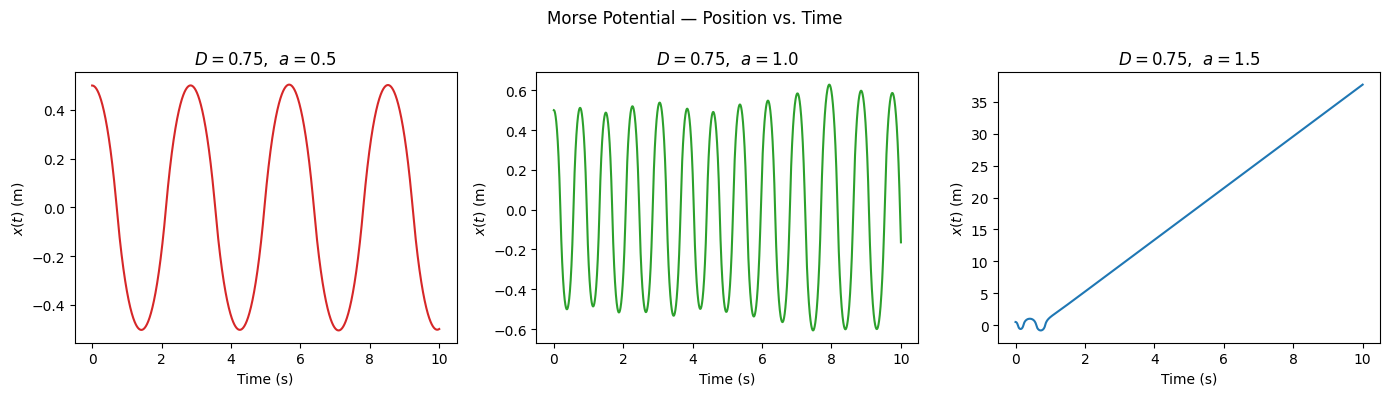

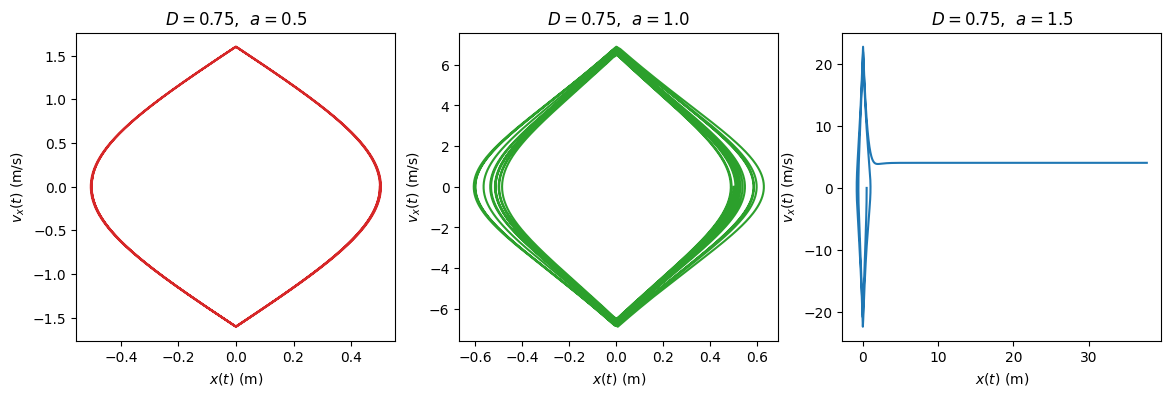

In [11]:
import numpy as np
import matplotlib.pyplot as plt
 
# --- Parameters ---
x0_scat, y0_scat = 0.5, 0.0
vx0_scat, vy0_scat = 0.0, 0.0
D, a, r0 = 0.75, 1.0, 2.0
t_start, t_end = 0.0, 10.0
Nt = 4_000
h  = (t_end - t_start) / (Nt - 1)
 
def morse_force_components(x, y):
    """Returns (Fx, Fy) from the Morse potential."""
    r  = np.sqrt(x**2 + y**2)
    fr = 2 * D * a * (np.exp(-a*(r - r0)) - np.exp(-2*a*(r - r0)))
    return fr * x / r, fr * y / r
 
def derivatives_morse(t, x, y, vx, vy):
    fx, fy = morse_force_components(x, y)
    return [vx, vy, fx, fy]
 
def initialize(a_param):
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist, tr, a
    a = a_param
    t, x, y, vx, vy = t_start, x0_scat, y0_scat, vx0_scat, vy0_scat
    x_hist, y_hist   = [x],  [y]
    vx_hist, vy_hist = [vx], [vy]
    tr = [t]
 
def observe():
    global t, x, y, vx, vy, x_hist, y_hist, vx_hist, vy_hist, tr
    x_hist.append(x);   y_hist.append(y)
    vx_hist.append(vx); vy_hist.append(vy)
    tr.append(t)
 
def rk4_step_morse():
    global t, x, y, vx, vy
    k0 = derivatives_morse(t,       x,            y,            vx,            vy)
    k1 = derivatives_morse(t+h/2,   x+h*k0[0]/2, y+h*k0[1]/2, vx+h*k0[2]/2, vy+h*k0[3]/2)
    k2 = derivatives_morse(t+h/2,   x+h*k1[0]/2, y+h*k1[1]/2, vx+h*k1[2]/2, vy+h*k1[3]/2)
    k3 = derivatives_morse(t+h,     x+h*k2[0],   y+h*k2[1],   vx+h*k2[2],   vy+h*k2[3])
    t  += h
    x  += h * (k0[0] + 2*k1[0] + 2*k2[0] + k3[0]) / 6
    y  += h * (k0[1] + 2*k1[1] + 2*k2[1] + k3[1]) / 6
    vx += h * (k0[2] + 2*k1[2] + 2*k2[2] + k3[2]) / 6
    vy += h * (k0[3] + 2*k1[3] + 2*k2[3] + k3[3]) / 6
 
# --- Simulation & plot ---
a_values = [0.5, 1.0, 1.5]
colors    = ["tab:red", "tab:green", "tab:blue"]
 
fig_time, ax_time = plt.subplots(1, len(a_values), figsize=(14, 4))
fig_phase, ax_phase = plt.subplots(1, len(a_values), figsize=(14, 4))
 
for j, (a_val, color) in enumerate(zip(a_values, colors)):
    initialize(a_val)
    for _ in range(Nt):
        rk4_step_morse()
        observe()
 
    ax_time[j].plot(tr, x_hist, color=color)
    ax_time[j].set_xlabel("Time (s)")
    ax_time[j].set_ylabel("$x(t)$ (m)")
    ax_time[j].set_title(f"$D={D}$,  $a={a_val}$")
 
    ax_phase[j].plot(x_hist, vx_hist, color=color)
    ax_phase[j].set_xlabel("$x(t)$ (m)")
    ax_phase[j].set_ylabel("$v_x(t)$ (m/s)")
    ax_phase[j].set_title(f"$D={D}$,  $a={a_val}$")
 
fig_time.suptitle("Morse Potential — Position vs. Time")
fig_time.tight_layout()
plt.show()
 
fig_phase.suptitle("Morse Potential — Phase Portraits")
fig_phase.tight_layout()
plt.show()

---
## 15. Motion in a Rotating Reference Frame

In a frame rotating at angular velocity $\Omega$ about the $z$-axis, two
**fictitious forces** appear on a particle of mass $m$:

$$\mathbf{F}_\text{Coriolis} = -2m\,\boldsymbol\Omega \times \mathbf{v}_\text{rot},
\qquad \mathbf{F}_\text{centrifugal} = -m\,\boldsymbol\Omega\times(\boldsymbol\Omega\times\mathbf{r})$$

For $\boldsymbol\Omega = \Omega\hat{z}$ and no external forces, the equations in 2D are:

$$\ddot{x} = 2\Omega\dot{y} + \Omega^2 x, \qquad \ddot{y} = -2\Omega\dot{x} + \Omega^2 y$$

We launch a particle in a **straight line** in the inertial frame and display what
an observer fixed to the rotating platform sees — the hallmark curved path.

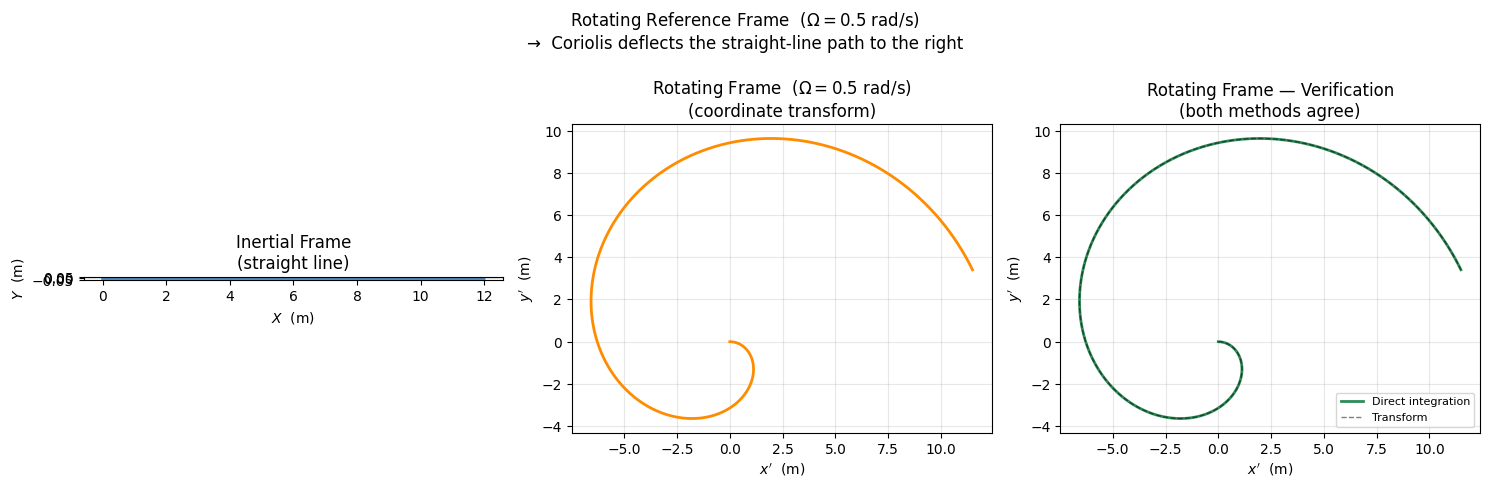

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
Omega = 0.5     # rotation rate of the frame (rad/s)
v0    = 1.0     # initial speed in the inertial frame (m/s)
tf    = 12.0    # simulation time (s)
h     = 0.01    # time step

# --- Inertial frame: free particle moving in the +x direction ---
# x_in(t) = v0*t,  y_in(t) = 0
t_arr = np.arange(0, tf, h)
x_in  = v0 * t_arr
y_in  = np.zeros_like(t_arr)

# --- Transform to rotating frame ---
# x_rot =  x_in * cos(Ωt) + y_in * sin(Ωt)
# y_rot = -x_in * sin(Ωt) + y_in * cos(Ωt)
x_rot_transform =  x_in * np.cos(Omega * t_arr) + y_in * np.sin(Omega * t_arr)
y_rot_transform = -x_in * np.sin(Omega * t_arr) + y_in * np.cos(Omega * t_arr)

# --- Direct integration of rotating-frame equations (verification) ---
def rot_frame_derivs(t, xr, yr, vxr, vyr):
    ax = 2*Omega*vyr + Omega**2 * xr
    ay = -2*Omega*vxr + Omega**2 * yr
    return [vxr, vyr, ax, ay]

def rk4_rotating(t, xr, yr, vxr, vyr):
    k0 = rot_frame_derivs(t,     xr,          yr,          vxr,          vyr)
    k1 = rot_frame_derivs(t+h/2, xr+h*k0[0]/2, yr+h*k0[1]/2, vxr+h*k0[2]/2, vyr+h*k0[3]/2)
    k2 = rot_frame_derivs(t+h/2, xr+h*k1[0]/2, yr+h*k1[1]/2, vxr+h*k1[2]/2, vyr+h*k1[3]/2)
    k3 = rot_frame_derivs(t+h,   xr+h*k2[0],   yr+h*k2[1],   vxr+h*k2[2],   vyr+h*k2[3])
    xr  += h*(k0[0]+2*k1[0]+2*k2[0]+k3[0])/6
    yr  += h*(k0[1]+2*k1[1]+2*k2[1]+k3[1])/6
    vxr += h*(k0[2]+2*k1[2]+2*k2[2]+k3[2])/6
    vyr += h*(k0[3]+2*k1[3]+2*k2[3]+k3[3])/6
    return xr, yr, vxr, vyr

# In the rotating frame at t=0: particle is at (0,0) with velocity (v0, 0)
# The velocity transforms as: v_rot = v_in - Ω×r  →  (v0 - 0, 0) at origin
t_eq = 0.0; xr_eq = 0.0; yr_eq = 0.0; vxr_eq = v0; vyr_eq = 0.0
xr_direct, yr_direct = [xr_eq], [yr_eq]
for _ in range(len(t_arr) - 1):
    xr_eq, yr_eq, vxr_eq, vyr_eq = rk4_rotating(t_eq, xr_eq, yr_eq, vxr_eq, vyr_eq)
    t_eq += h
    xr_direct.append(xr_eq)
    yr_direct.append(yr_eq)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x_in, y_in, "steelblue", lw=2)
axes[0].set_xlabel("$X$  (m)"); axes[0].set_ylabel("$Y$  (m)")
axes[0].set_title("Inertial Frame\n(straight line)")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_rot_transform, y_rot_transform, "darkorange", lw=2)
axes[1].set_xlabel("$x'$  (m)"); axes[1].set_ylabel("$y'$  (m)")
axes[1].set_title(f"Rotating Frame  ($\\Omega={Omega}$ rad/s)\n(coordinate transform)")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3)

axes[2].plot(xr_direct, yr_direct, "seagreen", lw=2, label="Direct integration")
axes[2].plot(x_rot_transform, y_rot_transform, "k--", lw=1, alpha=0.5, label="Transform")
axes[2].set_xlabel("$x'$  (m)"); axes[2].set_ylabel("$y'$  (m)")
axes[2].set_title("Rotating Frame — Verification\n(both methods agree)")
axes[2].set_aspect("equal"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle(rf"Rotating Reference Frame  ($\Omega = {Omega}$ rad/s)"
             "\n→  Coriolis deflects the straight-line path to the right")
fig.tight_layout()
plt.show()

---
## 16. Rigid-Body Rotation — Euler's Equations

For a **torque-free rigid body** the angular velocity in the body frame obeys:

$$I_1\dot\omega_1 = (I_2 - I_3)\,\omega_2\omega_3$$
$$I_2\dot\omega_2 = (I_3 - I_1)\,\omega_3\omega_1$$
$$I_3\dot\omega_3 = (I_1 - I_2)\,\omega_1\omega_2$$

Rotation about the **principal axis with the largest or smallest** moment of inertia
is **stable**; rotation about the **intermediate** axis is **unstable** — any tiny
perturbation causes the body to tumble (the *tennis-racket theorem*).

We also show the symmetric top ($I_1 = I_2 \neq I_3$) undergoing simple body-frame
precession of $\omega_1, \omega_2$ around the symmetry axis.

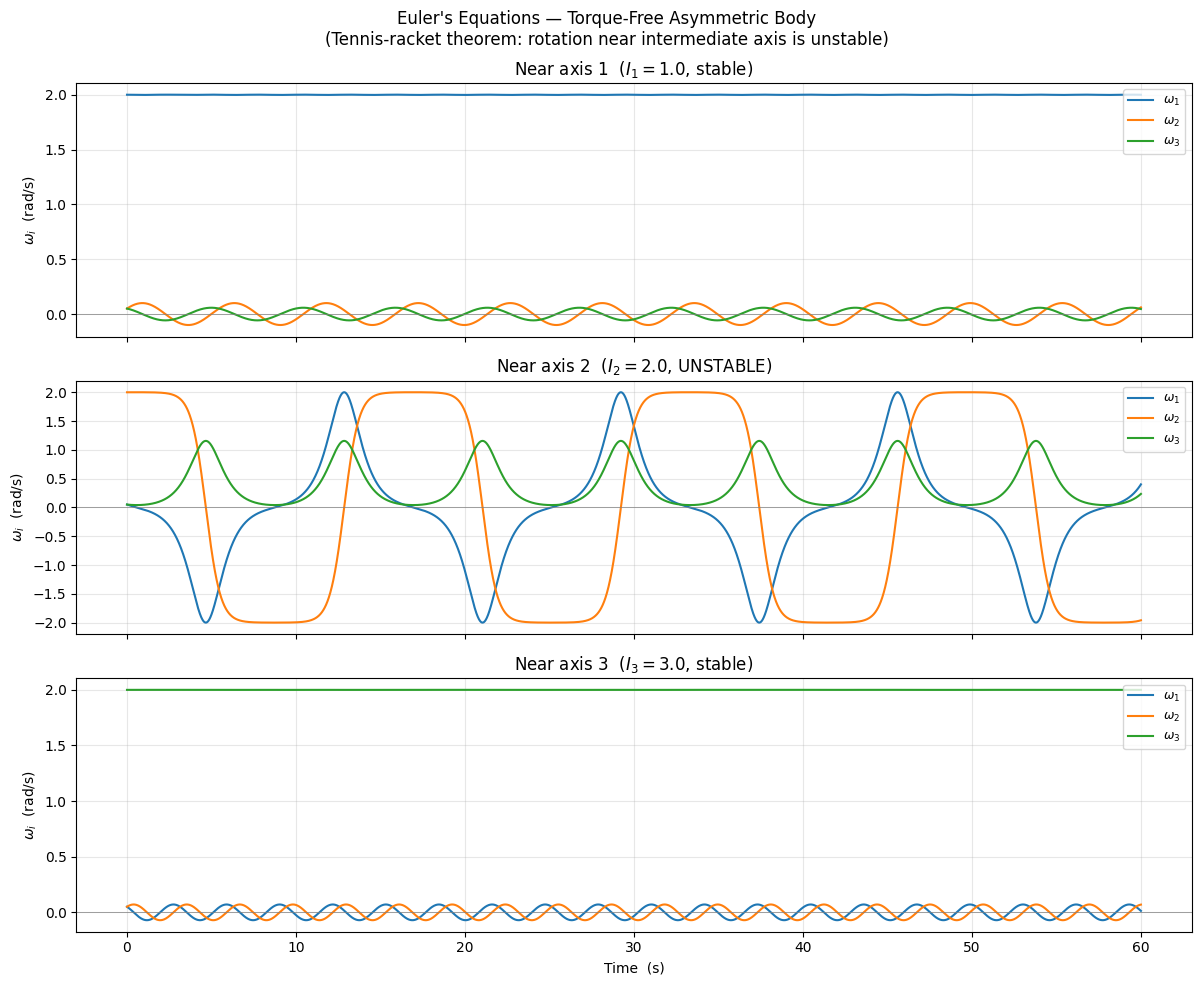

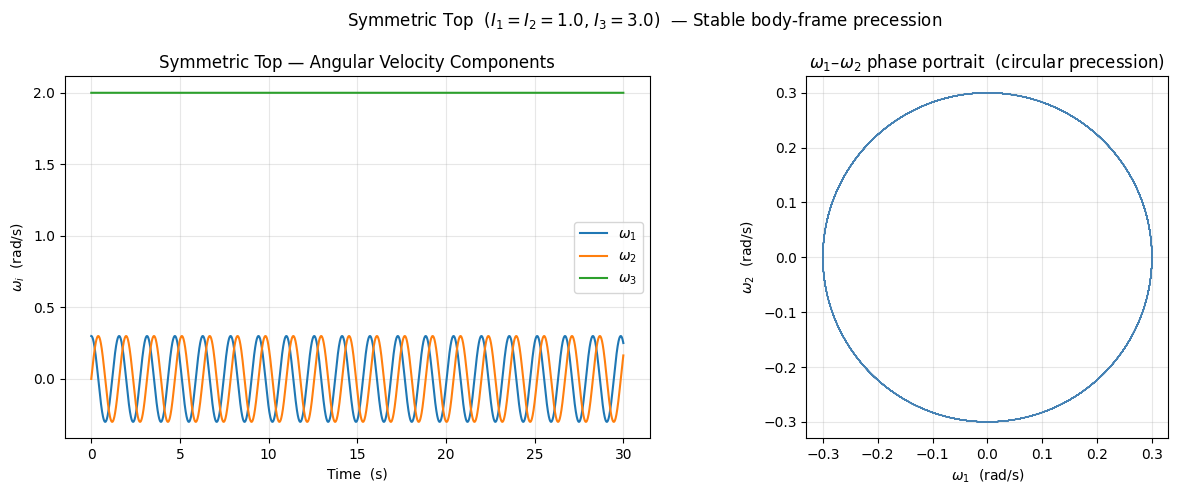

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- Moments of inertia (asymmetric body: I1 < I2 < I3) ---
I1, I2, I3 = 1.0, 2.0, 3.0

h_euler = 0.01
tf_euler = 60.0
N_euler  = int(tf_euler / h_euler)

def euler_eqs_derivs(omega):
    w1, w2, w3 = omega
    dw1 = (I2 - I3) / I1 * w2 * w3
    dw2 = (I3 - I1) / I2 * w3 * w1
    dw3 = (I1 - I2) / I3 * w1 * w2
    return np.array([dw1, dw2, dw3])

def rk4_euler(omega):
    k0 = euler_eqs_derivs(omega)
    k1 = euler_eqs_derivs(omega + h_euler*k0/2)
    k2 = euler_eqs_derivs(omega + h_euler*k1/2)
    k3 = euler_eqs_derivs(omega + h_euler*k2)
    return omega + h_euler*(k0 + 2*k1 + 2*k2 + k3)/6

# Three cases: initial ω near each principal axis, with a small perturbation ε
eps = 0.05
omega0_cases = {
    f"Near axis 1  ($I_1 = {I1}$, stable)":       np.array([2.0, eps, eps]),
    f"Near axis 2  ($I_2 = {I2}$, UNSTABLE)":     np.array([eps, 2.0, eps]),
    f"Near axis 3  ($I_3 = {I3}$, stable)":       np.array([eps, eps, 2.0]),
}

t_arr = np.linspace(0, tf_euler, N_euler)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, (label, omega0) in zip(axes, omega0_cases.items()):
    omega = omega0.copy()
    w1_h, w2_h, w3_h = [omega[0]], [omega[1]], [omega[2]]
    for _ in range(N_euler - 1):
        omega = rk4_euler(omega)
        w1_h.append(omega[0]); w2_h.append(omega[1]); w3_h.append(omega[2])
    ax.plot(t_arr, w1_h, label=r"$\omega_1$")
    ax.plot(t_arr, w2_h, label=r"$\omega_2$")
    ax.plot(t_arr, w3_h, label=r"$\omega_3$")
    ax.set_ylabel("$\\omega_i$  (rad/s)")
    ax.set_title(label)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", lw=0.5)

axes[-1].set_xlabel("Time  (s)")
fig.suptitle("Euler's Equations — Torque-Free Asymmetric Body\n"
             "(Tennis-racket theorem: rotation near intermediate axis is unstable)",
             fontsize=12)
fig.tight_layout()
plt.show()

# --- Symmetric top: I1 = I2 ≠ I3 ---
I1s, I2s, I3s = 1.0, 1.0, 3.0
omega0_sym = np.array([0.3, 0.0, 2.0])   # spinning about I3 with small tilt

def euler_sym_derivs(omega):
    w1, w2, w3 = omega
    dw1 = (I2s - I3s) / I1s * w2 * w3
    dw2 = (I3s - I1s) / I2s * w3 * w1
    dw3 = (I1s - I2s) / I3s * w1 * w2
    return np.array([dw1, dw2, dw3])

omega = omega0_sym.copy()
w1_h, w2_h, w3_h = [omega[0]], [omega[1]], [omega[2]]
tf_sym = 30.0; N_sym = int(tf_sym / h_euler)
for _ in range(N_sym - 1):
    k0 = euler_sym_derivs(omega)
    k1 = euler_sym_derivs(omega + h_euler*k0/2)
    k2 = euler_sym_derivs(omega + h_euler*k1/2)
    k3 = euler_sym_derivs(omega + h_euler*k2)
    omega += h_euler*(k0+2*k1+2*k2+k3)/6
    w1_h.append(omega[0]); w2_h.append(omega[1]); w3_h.append(omega[2])

t_sym = np.linspace(0, tf_sym, N_sym)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t_sym, w1_h, label=r"$\omega_1$")
axes[0].plot(t_sym, w2_h, label=r"$\omega_2$")
axes[0].plot(t_sym, w3_h, label=r"$\omega_3$")
axes[0].set_xlabel("Time  (s)"); axes[0].set_ylabel("$\\omega_i$  (rad/s)")
axes[0].set_title("Symmetric Top — Angular Velocity Components")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(w1_h, w2_h, lw=0.8, color="steelblue")
axes[1].set_xlabel(r"$\omega_1$  (rad/s)"); axes[1].set_ylabel(r"$\omega_2$  (rad/s)")
axes[1].set_title(r"$\omega_1$–$\omega_2$ phase portrait  (circular precession)")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3)

fig.suptitle(rf"Symmetric Top  ($I_1=I_2={I1s}$, $I_3={I3s}$)  — Stable body-frame precession")
fig.tight_layout()
plt.show()

---
## 17. The Brachistochrone Problem

**Question:** what is the curve connecting two points $(0,0)$ and $(a, b)$
(with $b$ below $a$) along which a particle slides from rest in the *shortest time*?

The answer, derived by Bernoulli in 1696, is a **cycloid**:

$$x(\varphi) = R(\varphi - \sin\varphi), \quad y(\varphi) = R(1 - \cos\varphi)$$

Its remarkable transit time is $T = \varphi_f\sqrt{R/g}$.

We compare three paths from $(0,0)$ to $(\pi, 2)$ (where $y$ increases downward),
integrating the transit time numerically as $T = \int ds/v$ with $v = \sqrt{2gy}$:

| Path | Description |
|---|---|
| **Cycloid** | Variational optimum |
| **Straight line** | Shortest geometric distance |
| **Vertical + Horizontal** | Maximise downward drop first |

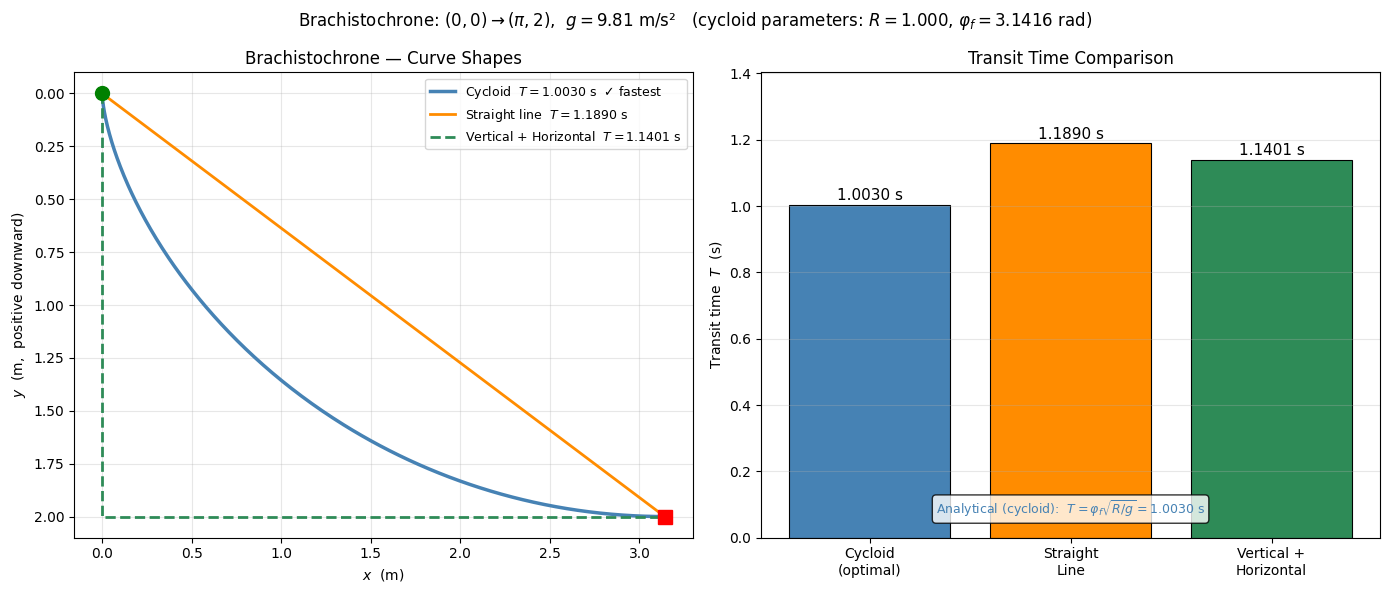


Summary of transit times:
  Cycloid (numerical):   1.003033 s
  Cycloid (analytical):  1.003033 s
  Straight line:         1.189043 s   (+18.5% slower)
  Vertical+Horizontal:   1.140068 s   (+13.7% slower)


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

g     = 9.81          # gravitational acceleration (m/s²)
a_end = np.pi         # horizontal span (m)
b_end = 2.0           # vertical drop (m, positive downward)

# ─────────────────────────────────────────────────
# 1. CYCLOID  (exact parametric endpoint: R=1, φ_f=π)
# ─────────────────────────────────────────────────
# Solve (φ_f - sin φ_f)/(1 - cos φ_f) = a_end/b_end  for φ_f
ratio = a_end / b_end    # = π/2  →  φ_f = π  (exact for this endpoint)

def cycloid_residual(phi):
    if abs(phi) < 1e-10: return -ratio
    return (phi - np.sin(phi)) / (1 - np.cos(phi)) - ratio

phi_f = brentq(cycloid_residual, 1e-4, 2*np.pi - 1e-4)
R_cy  = b_end / (1 - np.cos(phi_f))

phi_arr  = np.linspace(1e-6, phi_f, 400)
x_cy     = R_cy * (phi_arr - np.sin(phi_arr))
y_cy     = R_cy * (1 - np.cos(phi_arr))

# Analytical transit time: T = φ_f * √(R/g)
T_cycloid_analytic = phi_f * np.sqrt(R_cy / g)

def cycloid_integrand(phi):
    y = R_cy * (1 - np.cos(phi))
    if y <= 0:
        return 0.0
    dxdphi = R_cy * (1 - np.cos(phi))
    dydphi = R_cy * np.sin(phi)
    ds = np.sqrt(dxdphi**2 + dydphi**2)
    return ds / np.sqrt(2 * g * y)

T_cycloid_num, _ = quad(cycloid_integrand, 1e-7, phi_f)

# ─────────────────────────────────────────────────
# 2. STRAIGHT LINE  from (0,0) to (a_end, b_end)
# ─────────────────────────────────────────────────
slope   = b_end / a_end   # = 2/π
x_line  = np.linspace(0, a_end, 400)
y_line  = slope * x_line

def line_integrand(x):
    y = slope * x
    if y <= 0:
        return 0.0
    ds = np.sqrt(1 + slope**2)
    return ds / np.sqrt(2 * g * y)

T_line, _ = quad(line_integrand, 1e-7, a_end)

# ─────────────────────────────────────────────────
# 3. VERTICAL-THEN-HORIZONTAL PATH
#    Drop vertically from (0,0) to (0, b_end), then slide horizontally to (a_end, b_end)
# ─────────────────────────────────────────────────
x_vh = np.concatenate([np.zeros(200), np.linspace(0, a_end, 200)])
y_vh = np.concatenate([np.linspace(0, b_end, 200), np.full(200, b_end)])

# Segment 1: vertical drop  y from 0→b_end  (ds = dy)
T_vert, _ = quad(lambda y: 1/np.sqrt(2*g*y), 1e-7, b_end)

# Segment 2: horizontal slide at height b_end (ds = dx,  v = √(2g·b_end))
T_horiz = a_end / np.sqrt(2 * g * b_end)

T_vh = T_vert + T_horiz

# ─────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: curve shapes
axes[0].plot(x_cy,   y_cy,   "steelblue", lw=2.5,
             label=rf"Cycloid  $T = {T_cycloid_num:.4f}$ s  ✓ fastest")
axes[0].plot(x_line, y_line, "darkorange", lw=2.0,
             label=rf"Straight line  $T = {T_line:.4f}$ s")
axes[0].plot(x_vh,   y_vh,   "seagreen",  lw=2.0, ls="--",
             label=rf"Vertical + Horizontal  $T = {T_vh:.4f}$ s")
axes[0].invert_yaxis()   # y increases downward (gravity direction)
axes[0].set_xlabel("$x$  (m)")
axes[0].set_ylabel("$y$  (m,  positive downward)")
axes[0].set_title("Brachistochrone — Curve Shapes")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].plot(0, 0, "go", markersize=10, zorder=5)
axes[0].plot(a_end, b_end, "rs", markersize=10, zorder=5)

# Right: transit time bar chart
paths  = ["Cycloid\n(optimal)", "Straight\nLine", "Vertical +\nHorizontal"]
times  = [T_cycloid_num, T_line, T_vh]
colors = ["steelblue", "darkorange", "seagreen"]
bars   = axes[1].bar(paths, times, color=colors, edgecolor="k", linewidth=0.8)
for bar, T in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, T + 0.005,
                 f"{T:.4f} s", ha="center", va="bottom", fontsize=11)
axes[1].set_ylabel("Transit time  $T$  (s)")
axes[1].set_title("Transit Time Comparison")
axes[1].set_ylim(0, max(times) * 1.18)
axes[1].grid(True, alpha=0.3, axis="y")

analytical_txt = (f"Analytical (cycloid):  $T = \\varphi_f\\sqrt{{R/g}}"
                  f"= {T_cycloid_analytic:.4f}$ s")
axes[1].text(0.5, 0.05, analytical_txt, transform=axes[1].transAxes,
             ha="center", fontsize=9, color="steelblue",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

fig.suptitle(rf"Brachistochrone: $(0,0) \to (\pi, 2)$,  $g = {g}$ m/s²"
             rf"   (cycloid parameters: $R = {R_cy:.3f}$, $\varphi_f = {phi_f:.4f}$ rad)")
fig.tight_layout()
plt.show()

print(f"\nSummary of transit times:")
print(f"  Cycloid (numerical):   {T_cycloid_num:.6f} s")
print(f"  Cycloid (analytical):  {T_cycloid_analytic:.6f} s")
print(f"  Straight line:         {T_line:.6f} s   (+{(T_line/T_cycloid_num-1)*100:.1f}% slower)")
print(f"  Vertical+Horizontal:   {T_vh:.6f} s   (+{(T_vh/T_cycloid_num-1)*100:.1f}% slower)")